In [2]:
import numpy as np
import asyncio
import websockets
from pydantic import BaseModel
import nest_asyncio
nest_asyncio.apply()
import json
from ClassPVPOKE import PVPokeEnv
import gymnasium as gym

# Inicializar el entorno
env = PVPokeEnv("ws://localhost:8000/ws", "notebook", "pvpoke", battle_format = "1v1")
env.loop.run_until_complete(env.connect())


Connected to the server.


In [3]:
#high and low
print(env.observation_space.high)
print(env.observation_space.low)
print(env.action_space.n)
# Calcular el tamaño del espacio de estados discretos
state_bins = env.observation_space.high + 1  # +1 porque los valores son inclusivos
state_space_size = int(np.prod(state_bins))  # Número total de combinaciones posibles de estados discretos
action_space_size = env.action_space.n
print(state_space_size)
env.close()

[10 10  2 10 10  2]
[ 0 -1  0  0 -1  0]
4
131769
WebSocket connection closed.


# Evaluacion con Numpy

In [ ]:
import os
import numpy as np
import asyncio
import websockets
from pydantic import BaseModel
import nest_asyncio
nest_asyncio.apply()
import json
from collections import deque, defaultdict
from ClassPVPOKE import PVPokeEnv
import gymnasium as gym
from torch.utils.tensorboard import SummaryWriter
import time
from tqdm.notebook import tqdm
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Grid search parameters
param_grid = {
    'alpha': [0.1],          # Learning rates to test
    'epsilon': [1],          # Initial exploration rates to test  
    'gamma': [0.9, 0.999, 1],  # Discount factors to test
    'epsilon_min': [0.01, 0.05, 0.1]  # Minimum epsilon values to test
}


# Create all combinations
param_combinations = list(itertools.product(
    param_grid['alpha'], 
    param_grid['epsilon'], 
    param_grid['gamma'],
    param_grid['epsilon_min']  
))

# Generate grid search identifier
grid_name = "/NoOptimistic/grid_search_RewardWinLoss"  # Use a fixed name that will persist between runs
grid_base_dir = f"./experiments/Mantine-Gliglar-Terminal-Final/{grid_name}"
os.makedirs(grid_base_dir, exist_ok=True)

# After creating the grid_base_dir, add this code to save/check parameters consistency
param_file = f"{grid_base_dir}/parameters.json"
if os.path.exists(param_file):
    # Check if we're using the same parameters as before
    with open(param_file, 'r') as f:
        saved_params = json.load(f)
    
    # If parameters don't match, warn the user but continue
    if saved_params != param_grid:
        print("WARNING: Current parameter grid differs from previous run!")
        print("Previous:", saved_params)
        print("Current:", param_grid)
        continue_anyway = input("Continue with new parameters? (y/n): ")
        if continue_anyway.lower() != 'y':
            raise ValueError("Aborting to prevent parameter mismatch")
else:
    # First time running this grid search, save the parameters
    with open(param_file, 'w') as f:
        json.dump(param_grid, f)


# Create results tracking dataframe
results_file = f"{grid_base_dir}/grid_results.csv"
if os.path.exists(results_file):
    results_df = pd.read_csv(results_file)
    # Identify completed configurations
    completed_params = set(zip(
        results_df['alpha'].tolist(), 
        results_df['epsilon'].tolist(), 
        results_df['gamma'].tolist(),
        results_df['epsilon_min'].tolist()  # Añadir epsilon_min
    ))
else:
    results_df = pd.DataFrame(columns=[
        'alpha', 'epsilon', 'gamma', 'epsilon_min',  # Añadir epsilon_min
        'win_rate', 'avg_reward', 
        'episodes_completed', 'states_visited_percent',
        'training_time'
    ])
    completed_params = set()

# Función para discretizar el estado - keep this global
def discretize_state(state):
    return tuple(state.astype(int))

# --- Parámetros de epsilon decay ---
epsilon_start = None
epsilon_end = 0.01  # Valor mínimo de epsilon
epsilon_decay_episodes = None

def get_epsilon(episode):
    if episode >= epsilon_decay_episodes:
        return epsilon_end
    else:
        # Decaimiento lineal
        return epsilon_start - (epsilon_start - epsilon_end) * (episode / epsilon_decay_episodes)

# ...existing code...

def run_configuration(alpha_val, epsilon_val, gamma_val, epsilon_min_val, max_episodes=20000):
    """Run a single hyperparameter configuration training"""
    # Create experiment directory for this configuration
    config_name = f"alpha{alpha_val}_epsilon{epsilon_val}_gamma{gamma_val}_epsilonmin{epsilon_min_val}"
    experiment_dir = f"{grid_base_dir}/{config_name}"
    os.makedirs(experiment_dir, exist_ok=True)
    os.makedirs(f"{experiment_dir}/q_table", exist_ok=True)
    os.makedirs(f"{experiment_dir}/visit_count", exist_ok=True)
    os.makedirs(f"{experiment_dir}/checkpoints", exist_ok=True)
    
    # Initialize environment
    env = PVPokeEnv("ws://localhost:8000/ws", "notebook", "pvpoke",battle_format="1v1")
    env.loop.run_until_complete(env.connect())
    
    # Calcular el tamaño del espacio de estados discretos
    state_bins = env.observation_space.high + 1
    state_space_size = int(np.prod(state_bins))
    action_space_size = env.action_space.n
    
    # Training hyperparameters
    global epsilon_start, epsilon_end, epsilon_decay_episodes
    epsilon_start = epsilon_val
    epsilon_end = epsilon_min_val  # Usar el valor pasado como parámetro
    epsilon_decay_episodes = int(max_episodes * 0.5)
    epsilon = epsilon_val  # Este valor será actualizado cada episodioo

    # Q-table y visit_counts como arrays NumPy
    Q = np.zeros((state_space_size, action_space_size), dtype=np.float32)
    visit_counts = np.zeros((state_space_size, action_space_size), dtype=np.int32)

    # TensorBoard
    writer = SummaryWriter(log_dir=f"{experiment_dir}/runs")
    
    # Evaluation parameters
    win_rate_threshold = 0.9
    save_interval = 500
    evaluation_interval = 500
    checkpoint_interval = 500
    num_test_episodes = 10

    block_size = 100
    block_td_errors = []
    block_counter = 0

    # Checkpoint loading
    checkpoint_files = [f for f in os.listdir(f"{experiment_dir}/checkpoints") if f.startswith("training_state_")]
    if checkpoint_files:
        latest_episode = max([int(f.split("_")[-1].split(".")[0]) for f in checkpoint_files])
        print(f"Resuming from checkpoint at episode {latest_episode}")

        npy_q_table_path = f"{experiment_dir}/q_table/q_table_episode_{latest_episode}.npy"
        npy_visit_path = f"{experiment_dir}/visit_count/visit_counts_episode_{latest_episode}.npy"

        if os.path.exists(npy_q_table_path):
            Q = np.load(npy_q_table_path)
        if os.path.exists(npy_visit_path):
            visit_counts = np.load(npy_visit_path)

        checkpoint = np.load(f"{experiment_dir}/checkpoints/training_state_{latest_episode}.npy", allow_pickle=True).item()
        epsilon = checkpoint.get('epsilon', epsilon_val)
        td_error_history = deque(checkpoint.get('td_error_history', []), maxlen=100)
        episode_steps_history = list(checkpoint.get('episode_steps_history', []))
        accumulated_train_time = checkpoint.get('accumulated_train_time', 0)
        accumulated_frames = checkpoint.get('accumulated_frames', 0)
        last_saved_episode = latest_episode
    else:
        td_error_history = deque(maxlen=100)
        episode_steps_history = []
        accumulated_train_time = 0
        accumulated_frames = 0
        last_saved_episode = 0

    def choose_action(state):
        state_index = np.ravel_multi_index(state, state_bins)
        if np.random.rand() < epsilon:
            return np.random.randint(action_space_size)
        else:
            q_values = Q[state_index]
            max_indices = np.where(q_values == np.max(q_values))[0]
            return np.random.choice(max_indices)

    def choose_action_greedy(state):
        state_index = np.ravel_multi_index(state, state_bins)
        q_values = Q[state_index]
        max_indices = np.where(q_values == np.max(q_values))[0]
        return np.random.choice(max_indices)

    def evaluate_policy():
        total_rewards = []
        total_wins = 0
        eval_frames = 0
        eval_start_time = time.time()
        for episode in range(num_test_episodes):
            state, _ = env.reset()
            state = discretize_state(state)
            total_reward = 0
            done = False
            while not done:
                action = choose_action_greedy(state)

                next_state, reward, done, _, _ = env.step(action)
                next_state = discretize_state(next_state)
                state = next_state
                total_reward += reward
                eval_frames += 1
                if done:
                    episode_final_reward = reward
            if episode_final_reward >= 0:
                total_wins += 1
            total_rewards.append(total_reward)
        eval_end_time = time.time()
        eval_fps = eval_frames / (eval_end_time - eval_start_time) if (eval_end_time - eval_start_time) > 0 else 0
        average_reward = np.mean(total_rewards)
        win_rate = total_wins / num_test_episodes
        return average_reward, win_rate, eval_fps

    # Training loop
    total_steps = 0
    session_start_time = time.time()
    session_frames = 0
    train_start_time = time.time()

    remaining_episodes = max_episodes - last_saved_episode
    with tqdm(total=remaining_episodes, desc=f"Training {config_name}") as pbar:
        for episode in range(last_saved_episode, max_episodes):
            epsilon = get_epsilon(episode)
            state, _ = env.reset()
            state = discretize_state(state)
            total_reward = 0
            td_errors = []
            done = False
            steps_in_episode = 0
            while not done:

                state_index = np.ravel_multi_index(state, state_bins)
                action = choose_action(state)

                next_state, reward, done, _, _ = env.step(action)

                next_state = discretize_state(next_state)
                next_state_index = np.ravel_multi_index(next_state, state_bins)

                if done:
                    td_target = reward
                else:
                    best_next_action = np.argmax(Q[next_state_index])
                    td_target = reward + gamma_val * Q[next_state_index, best_next_action]

                td_error = td_target - Q[state_index, action]
                Q[state_index, action] += alpha_val * td_error

                visit_counts[state_index, action] += 1

                td_errors.append(abs(td_error))
                steps_in_episode += 1
                total_steps += 1
                session_frames += 1

                state = next_state

            episode_steps_history.append(steps_in_episode)
            td_error_history.append(np.mean(td_errors))
            block_td_errors.extend(td_errors)
            block_counter += 1

            if block_counter >= block_size:
                block_avg_td_error = np.mean(block_td_errors)
                block_median_td_error = np.median(block_td_errors)
                block_std_td_error = np.std(block_td_errors)
                writer.add_scalar("TD_Error_Block/Mean", block_avg_td_error, episode)
                writer.add_scalar("TD_Error_Block/Median", block_median_td_error, episode)
                writer.add_scalar("TD_Error_Block/StdDev", block_std_td_error, episode)
                block_td_errors = []
                block_counter = 0

            writer.add_scalar("Training/TD_Error", np.mean(td_errors), episode)
            writer.add_scalar("Training/Epsilon", epsilon, episode)

            pbar.set_postfix({
                'ε': f"{epsilon:.3f}",
                'TD-err': f"{np.mean(td_errors):.5f}" if td_errors else "N/A",
                'Steps': steps_in_episode
            })
            pbar.update(1)

            # Save Q-table and visit counts (NumPy only)
            if (episode + 1) % save_interval == 0:
                np.save(f"{experiment_dir}/q_table/q_table_episode_{episode + 1}.npy", Q)
                np.save(f"{experiment_dir}/visit_count/visit_counts_episode_{episode + 1}.npy", visit_counts)

                if (episode + 1) % evaluation_interval == 0:
                    average_reward, win_rate, eval_fps = evaluate_policy()
                    writer.add_scalar("Evaluation/Win_Rate", win_rate, episode + 1)
                    writer.add_scalar("Evaluation/Average_Reward", average_reward, episode + 1)
                    writer.add_scalar("Evaluation/Eval_FPS", eval_fps, episode + 1)

                    visited_states = np.count_nonzero(np.sum(visit_counts, axis=1))
                    percent_states_visited = (visited_states / state_space_size) * 100
                    writer.add_scalar("Coverage/States_Visited_Percent", percent_states_visited, episode + 1)

                    current_time = time.time()
                    session_duration = current_time - session_start_time
                    accumulated_train_time += session_duration
                    accumulated_frames += session_frames
                    training_fps = accumulated_frames / accumulated_train_time if accumulated_train_time > 0 else 0
                    writer.add_scalar("Training/Training_FPS", training_fps, episode + 1)

                    #print(f"\nEvaluation at episode {episode + 1}: Win rate: {win_rate:.2f}")
                    #print(f"States visited: {percent_states_visited:.2f}%")
                    #print(f"Training FPS: {training_fps:.1f}")

                    session_start_time = time.time()
                    session_frames = 0

                if (episode + 1) % checkpoint_interval == 0:
                    checkpoint = {
                        'episode': episode + 1,
                        'epsilon': epsilon,
                        'total_steps': total_steps,
                        'td_error_history': list(td_error_history),
                        'episode_steps_history': list(episode_steps_history[-100:]),
                        'accumulated_train_time': accumulated_train_time,
                        'accumulated_frames': accumulated_frames
                    }
                    np.save(f"{experiment_dir}/checkpoints/training_state_{episode + 1}.npy", checkpoint)
                    #print(f"Checkpoint saved at episode {episode + 1}")

    # Save final Q-table and visit counts as NumPy
    np.save(f"{experiment_dir}/q_table_final.npy", Q)
    np.save(f"{experiment_dir}/visit_counts_final.npy", visit_counts)

    final_avg_reward, final_win_rate, _ = evaluate_policy()
    visited_states = np.count_nonzero(np.sum(visit_counts, axis=1))
    percent_states_visited = (visited_states / state_space_size) * 100
    total_train_time = time.time() - train_start_time + accumulated_train_time

    env.close()
    writer.close()

    return {
        'win_rate': final_win_rate,
        'avg_reward': final_avg_reward,
        'episodes_completed': episode + 1,
        'states_visited_percent': percent_states_visited,
        'training_time': total_train_time
    }


# Main grid search loop
for i, (alpha_val, epsilon_val, gamma_val, epsilon_min_val) in enumerate(param_combinations):
    # Skip if already completed
    if (alpha_val, epsilon_val, gamma_val, epsilon_min_val) in completed_params:
        print(f"Skipping completed configuration: alpha={alpha_val}, epsilon={epsilon_val}, gamma={gamma_val}, epsilon_min={epsilon_min_val}")
        continue
        
    print(f"\n===== Configuration {i+1}/{len(param_combinations)} =====")
    print(f"Alpha: {alpha_val}, Epsilon: {epsilon_val}, Gamma: {gamma_val}, Epsilon Min: {epsilon_min_val}")
    
    try:
        # Run this configuration
        results = run_configuration(alpha_val, epsilon_val, gamma_val, epsilon_min_val)
        
        # Save results
        new_row = pd.DataFrame({
            'alpha': [alpha_val],
            'epsilon': [epsilon_val], 
            'gamma': [gamma_val],
            'epsilon_min': [epsilon_min_val],
            'win_rate': [results['win_rate']],
            'avg_reward': [results['avg_reward']],
            'episodes_completed': [results['episodes_completed']],
            'states_visited_percent': [results['states_visited_percent']],
            'training_time': [results['training_time']]
        })
        
        results_df = pd.concat([results_df, new_row], ignore_index=True)
        
        # Save updated results
        results_df.to_csv(f"{grid_base_dir}/grid_results.csv", index=False)
        
        # Mark as completed
        completed_params.add((alpha_val, epsilon_val, gamma_val))
        
        # Create a visualization after each configuration
        plt.figure(figsize=(15, 10))
        
        # Win rate by hyperparameter
        plt.subplot(2, 3, 1)
        for a in sorted(set(results_df['alpha'])):
            subset = results_df[results_df['alpha'] == a]
            plt.plot(subset.index, subset['win_rate'], 'o-', label=f"α={a}")
        plt.title("Win Rate by Alpha")
        plt.ylim(0, 1)
        plt.legend()
        
        plt.subplot(2, 3, 2)
        for e in sorted(set(results_df['epsilon'])):
            subset = results_df[results_df['epsilon'] == e]
            plt.plot(subset.index, subset['win_rate'], 'o-', label=f"ε={e}")
        plt.title("Win Rate by Epsilon")
        plt.ylim(0, 1)
        plt.legend()
        
        plt.subplot(2, 3, 3)
        for g in sorted(set(results_df['gamma'])):
            subset = results_df[results_df['gamma'] == g]
            plt.plot(subset.index, subset['win_rate'], 'o-', label=f"γ={g}")
        plt.title("Win Rate by Gamma")
        plt.ylim(0, 1)
        plt.legend()
        
        # State coverage
        plt.subplot(2, 3, 4)
        for a in sorted(set(results_df['alpha'])):
            subset = results_df[results_df['alpha'] == a]
            plt.plot(subset.index, subset['states_visited_percent'], 'o-', label=f"α={a}")
        plt.title("State Coverage by Alpha")
        plt.ylim(0, 100)
        plt.legend()
        
        # Avg reward
        plt.subplot(2, 3, 5)
        for e in sorted(set(results_df['epsilon'])):
            subset = results_df[results_df['epsilon'] == e]
            plt.plot(subset.index, subset['avg_reward'], 'o-', label=f"ε={e}")
        plt.title("Avg Reward by Epsilon")
        plt.legend()
        
        # Training time
        plt.subplot(2, 3, 6)
        for g in sorted(set(results_df['gamma'])):
            subset = results_df[results_df['gamma'] == g]
            plt.plot(subset.index, subset['training_time'] / 3600, 'o-', label=f"γ={g}")
        plt.title("Training Time (hours) by Gamma")
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(f"{grid_base_dir}/grid_results.png")
        plt.close()

        # Epsilon Min vs Win Rate
        plt.subplot(2, 4, 4)  # Ajustar el grid de visualización
        for e_min in sorted(set(results_df['epsilon_min'])):
            subset = results_df[results_df['epsilon_min'] == e_min]
            plt.plot(subset.index, subset['win_rate'], 'o-', label=f"ε_min={e_min}")
        plt.title("Win Rate by Epsilon Min")
        plt.ylim(0, 1)
        plt.legend()
        
    except Exception as e:
        print(f"Error in configuration: {e}")
        # Continue with next configuration

print("\nGrid search completed!")
print(results_df)

# Create a heatmap of win rates
if len(results_df) >= 4:  # Need at least a few data points for meaningful heatmap
    plt.figure(figsize=(15, 5))
    
    # Alpha vs Epsilon heatmap
    try:
        pivot = pd.pivot_table(results_df, values='win_rate', 
                              index='alpha', columns='epsilon', 
                              aggfunc=np.mean)
        plt.subplot(1, 3, 1)
        plt.imshow(pivot, cmap='viridis')
        plt.colorbar(label='Win Rate')
        plt.title('Win Rate: Alpha vs Epsilon')
        plt.xlabel('Epsilon')
        plt.ylabel('Alpha')
        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.yticks(range(len(pivot.index)), pivot.index)
    except:
        pass
    
    # Alpha vs Gamma heatmap
    try:
        pivot = pd.pivot_table(results_df, values='win_rate', 
                              index='alpha', columns='gamma', 
                              aggfunc=np.mean)
        plt.subplot(1, 3, 2)
        plt.imshow(pivot, cmap='viridis')
        plt.colorbar(label='Win Rate')
        plt.title('Win Rate: Alpha vs Gamma')
        plt.xlabel('Gamma')
        plt.ylabel('Alpha')
        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.yticks(range(len(pivot.index)), pivot.index)
    except:
        pass
    
    # Epsilon vs Gamma heatmap
    try:
        pivot = pd.pivot_table(results_df, values='win_rate', 
                              index='epsilon', columns='gamma', 
                              aggfunc=np.mean)
        plt.subplot(1, 3, 3)
        plt.imshow(pivot, cmap='viridis')
        plt.colorbar(label='Win Rate')
        plt.title('Win Rate: Epsilon vs Gamma')
        plt.xlabel('Gamma')
        plt.ylabel('Epsilon')
        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.yticks(range(len(pivot.index)), pivot.index)
    except:
        pass
    
    plt.tight_layout()
    plt.savefig(f"{grid_base_dir}/heatmap_results.png")
    plt.show()

# Print best configuration
if len(results_df) > 0:
    best_idx = results_df['win_rate'].idxmax()
    best_config = results_df.iloc[best_idx]
    print("\nBest configuration:")
    print(f"Alpha: {best_config['alpha']}, Epsilon: {best_config['epsilon']}, Gamma: {best_config['gamma']}")
    print(f"Win Rate: {best_config['win_rate']:.4f}, Avg Reward: {best_config['avg_reward']:.4f}")
    print(f"Training Time: {best_config['training_time']/3600:.2f} hours")

# Entrenamiento JSON

In [ ]:
import os
import numpy as np
import asyncio
import websockets
from pydantic import BaseModel
import nest_asyncio
nest_asyncio.apply()
import json
from collections import deque, defaultdict
from ClassPVPOKE import PVPokeEnv
import gymnasium as gym
from torch.utils.tensorboard import SummaryWriter
import time
from tqdm.notebook import tqdm
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Grid search parameters
param_grid = {
    'alpha': [0.1],          # Learning rates to test
    'epsilon': [1],          # Initial exploration rates to test  
    'gamma': [0.9, 0.999, 1],  # Discount factors to test
    'epsilon_min': [0.01, 0.05, 0.1]  # Minimum epsilon values to test
}

# Create all combinations
param_combinations = list(itertools.product(
    param_grid['alpha'], 
    param_grid['epsilon'], 
    param_grid['gamma'],
    param_grid['epsilon_min']  
))

# Generate grid search identifier
grid_name = "/NoOptimistic/grid_search_RewardWinLoss"  # Use a fixed name that will persist between runs
grid_base_dir = f"./experiments/Mantine-Gliglar-Terminal--20Niveles/{grid_name}"
os.makedirs(grid_base_dir, exist_ok=True)

# After creating the grid_base_dir, add this code to save/check parameters consistency
param_file = f"{grid_base_dir}/parameters.json"
if os.path.exists(param_file):
    # Check if we're using the same parameters as before
    with open(param_file, 'r') as f:
        saved_params = json.load(f)
    
    # If parameters don't match, warn the user but continue
    if saved_params != param_grid:
        print("WARNING: Current parameter grid differs from previous run!")
        print("Previous:", saved_params)
        print("Current:", param_grid)
        continue_anyway = input("Continue with new parameters? (y/n): ")
        if continue_anyway.lower() != 'y':
            raise ValueError("Aborting to prevent parameter mismatch")
else:
    # First time running this grid search, save the parameters
    with open(param_file, 'w') as f:
        json.dump(param_grid, f)

# Create results tracking dataframe
results_file = f"{grid_base_dir}/grid_results.csv"
if os.path.exists(results_file):
    results_df = pd.read_csv(results_file)
    # Identify completed configurations
    completed_params = set(zip(
        results_df['alpha'].tolist(), 
        results_df['epsilon'].tolist(), 
        results_df['gamma'].tolist(),
        results_df['epsilon_min'].tolist()
    ))
else:
    results_df = pd.DataFrame(columns=[
        'alpha', 'epsilon', 'gamma', 'epsilon_min',
        'win_rate', 'avg_reward', 
        'episodes_completed', 'states_visited_percent',
        'training_time'
    ])
    completed_params = set()

# Function to discretize the state - keep this global
def discretize_state(state):
    return tuple(state.astype(int))

# --- Epsilon decay parameters ---
epsilon_start = None
epsilon_end = None  # Will be set to epsilon_min_val
epsilon_decay_episodes = None

def get_epsilon(episode):
    if episode >= epsilon_decay_episodes:
        return epsilon_end
    else:
        # Linear decay
        return epsilon_start - (epsilon_start - epsilon_end) * (episode / epsilon_decay_episodes)

def run_configuration(alpha_val, epsilon_val, gamma_val, epsilon_min_val, max_episodes=20000):
    """Run a single hyperparameter configuration training"""
    # Create experiment directory for this configuration
    config_name = f"alpha{alpha_val}_epsilon{epsilon_val}_gamma{gamma_val}_epsilonmin{epsilon_min_val}"
    experiment_dir = f"{grid_base_dir}/{config_name}"
    os.makedirs(experiment_dir, exist_ok=True)
    os.makedirs(f"{experiment_dir}/q_table", exist_ok=True)
    os.makedirs(f"{experiment_dir}/visit_count", exist_ok=True)
    os.makedirs(f"{experiment_dir}/checkpoints", exist_ok=True)
    
    # Initialize environment
    env = PVPokeEnv("ws://localhost:8000/ws", "notebook", "pvpoke", battle_format="1v1")
    env.loop.run_until_complete(env.connect())
    
    # Calculate the size of the discrete state space
    state_bins = env.observation_space.high + 1
    state_space_size = int(np.prod(state_bins))
    action_space_size = env.action_space.n
    
    # Training hyperparameters
    global epsilon_start, epsilon_end, epsilon_decay_episodes
    epsilon_start = epsilon_val
    epsilon_end = epsilon_min_val
    epsilon_decay_episodes = int(max_episodes * 0.375)  # Decay during 37.5% of episodes (matching NumPy version)
    epsilon = epsilon_val  # Initial value, will be updated each episode

    # Configure TensorBoard for this run
    writer = SummaryWriter(log_dir=f"{experiment_dir}/runs")
    
    # Evaluation parameters
    win_rate_threshold = 0.9    # Stop if win rate exceeds this
    save_interval = 500        # Save Q-table interval (matching NumPy version)
    evaluation_interval = 500  # Evaluation interval (matching NumPy version)
    checkpoint_interval = 500  # Checkpoint interval (matching NumPy version)
    num_test_episodes = 20     # Test episodes per evaluation (matching NumPy version)

    block_size = 100  # Block size for analysis
    block_td_errors = []  # To store TD errors for the current block
    block_counter = 0  # Counter to know when to analyze a complete block
    
    # Look for existing checkpoint
    checkpoint_files = [f for f in os.listdir(f"{experiment_dir}/checkpoints") 
                      if f.startswith("training_state_")]
    
    if checkpoint_files:
        # Find the latest checkpoint
        latest_episode = max([int(f.split("_")[-1].split(".")[0]) for f in checkpoint_files])
        print(f"Resuming from checkpoint at episode {latest_episode}")
        
        # Initialize dictionary Q-table (without optimistic initialization)
        Q = defaultdict(lambda: defaultdict(float))  # Changed from int to float for consistency
        visit_counts = defaultdict(lambda: defaultdict(int))  # Initialize as dictionary
        
        # Check if NumPy (.npy) files exist
        npy_q_table_path = f"{experiment_dir}/q_table/q_table_episode_{latest_episode}.npy"
        json_q_table_path = f"{experiment_dir}/q_table/q_table_episode_{latest_episode}.json"
        
        if os.path.exists(npy_q_table_path):
            # Load original NumPy format and convert to dictionary
            print("Found NumPy format checkpoint, converting to dictionary...")
            np_Q = np.load(npy_q_table_path)
            
            # Check for NumPy visit counts
            npy_visit_path = f"{experiment_dir}/visit_count/visit_counts_episode_{latest_episode}.npy"
            if os.path.exists(npy_visit_path):
                np_visit_counts = np.load(npy_visit_path)
                # Convert NumPy visit counts to dictionary
                for state_idx in range(np_visit_counts.shape[0]):
                    for action in range(np_visit_counts.shape[1]):
                        if np_visit_counts[state_idx, action] > 0:
                            state_tuple = np.unravel_index(state_idx, state_bins)
                            visit_counts[state_tuple][action] = int(np_visit_counts[state_idx, action])
            else:
                print("WARNING: No visit counts found, initializing empty")
            
            # Convert NumPy array to dictionary
            for state_idx in range(np_Q.shape[0]):
                # Check using converted dictionary visit counts instead
                state_tuple = np.unravel_index(state_idx, state_bins)
                if any(visit_counts[state_tuple].values()):  # Only transfer visited states
                    for action in range(np_Q.shape[1]):
                        if visit_counts[state_tuple][action] > 0:
                            Q[state_tuple][action] = float(np_Q[state_idx, action])
            
            print("Successfully converted NumPy to dictionary format")
                
        elif os.path.exists(json_q_table_path):
            # Load JSON data for Q-table
            print("Found JSON format checkpoint, loading into dictionary...")
            with open(json_q_table_path, 'r') as f:
                q_dict = json.load(f)
                
            # Load JSON visit counts if available
            json_visit_path = f"{experiment_dir}/visit_count/visit_counts_episode_{latest_episode}.json"
            
            if os.path.exists(json_visit_path):
                # Load visit counts from JSON
                with open(json_visit_path, 'r') as f:
                    visit_dict = json.load(f)
                    
                # Convert visit dict to dictionary visit counts
                for state_str, actions in visit_dict.items():
                    state_tuple = tuple(map(int, state_str.strip('()').split(', ')))
                    for action_str, count in actions.items():
                        action = int(action_str)
                        visit_counts[state_tuple][action] = int(count)
            else:
                # Neither format exists - warning but continue
                print("WARNING: No visit counts found, initializing empty")
                
            # Convert JSON to dictionary Q-table
            for state_str, actions in q_dict.items():
                # Parse tuple string like '(0, 1, 2, 3, 4, 5)'
                state_tuple = tuple(map(int, state_str.strip('()').split(', ')))
                
                for action_str, q_value in actions.items():
                    action = int(action_str)
                    Q[state_tuple][action] = float(q_value)
        else:
            # Neither format exists - generate an error
            raise FileNotFoundError(f"No Q-table found for episode {latest_episode} in either NumPy or JSON format")
        
        # Continue with loading the rest of the checkpoint
        checkpoint = np.load(f"{experiment_dir}/checkpoints/training_state_{latest_episode}.npy", 
                            allow_pickle=True).item()

        # Initialize variables from checkpoint
        epsilon = checkpoint.get('epsilon', epsilon_val)  # Default to epsilon_val if not in checkpoint
        td_error_history = deque(checkpoint.get('td_error_history', []), maxlen=100)
        episode_steps_history = list(checkpoint.get('episode_steps_history', []))
        accumulated_train_time = checkpoint.get('accumulated_train_time', 0)
        accumulated_frames = checkpoint.get('accumulated_frames', 0)
    
        last_saved_episode = latest_episode
    else:
        # Initialize fresh Q-table and state
        Q = defaultdict(lambda: defaultdict(float))  # Changed from int to float for consistency
        visit_counts = defaultdict(lambda: defaultdict(int))  # Use dictionary approach consistently
        td_error_history = deque(maxlen=100)
        episode_steps_history = []
        accumulated_train_time = 0
        accumulated_frames = 0
        last_saved_episode = 0
    
    def choose_action(state):
        if np.random.rand() < epsilon:
            return env.action_space.sample()  # Random action
        else:
            # Get Q-values for this state
            q_values = [Q[state][a] for a in range(action_space_size)]
            max_q = max(q_values)
            # Find indices of actions with maximum Q-value
            max_indices = [i for i, q in enumerate(q_values) if q == max_q]
            # Return a random action among those with maximum value
            return np.random.choice(max_indices)

    def choose_action_greedy(state):
        # Get Q-values for this state
        q_values = [Q[state][a] for a in range(action_space_size)]
        max_q = max(q_values)
        # Find indices of actions with maximum Q-value
        max_indices = [i for i, q in enumerate(q_values) if q == max_q]
        # Return a random action among those with maximum value
        return np.random.choice(max_indices)
    
    # Evaluation function
    def evaluate_policy():
        total_rewards = []
        total_wins = 0
        eval_frames = 0
        eval_start_time = time.time()
    
        for episode in range(num_test_episodes):
            state, _ = env.reset()
            state = discretize_state(state)
            total_reward = 0
            episode_final_reward = 0
    
            done = False
            while not done:
                action = choose_action_greedy(state)
                next_state, reward, done, _, _ = env.step(action)
                next_state = discretize_state(next_state)
    
                state = next_state
                total_reward += reward
                eval_frames += 1
                if done:
                    episode_final_reward = reward  # Final reward for this episode
            
            if episode_final_reward >= 0:
                total_wins += 1
    
            total_rewards.append(total_reward)
    
        eval_end_time = time.time()
        eval_fps = eval_frames / (eval_end_time - eval_start_time) if (eval_end_time - eval_start_time) > 0 else 0
        average_reward = np.mean(total_rewards)
        win_rate = total_wins / num_test_episodes
        return average_reward, win_rate, eval_fps
    
    # Training loop
    total_steps = 0
    session_start_time = time.time()
    session_frames = 0
    train_start_time = time.time()
    
    remaining_episodes = max_episodes - last_saved_episode
    with tqdm(total=remaining_episodes, desc=f"Training {config_name}") as pbar:
        for episode in range(last_saved_episode, max_episodes):
            epsilon = get_epsilon(episode)  # Update epsilon each episode
            state, _ = env.reset()
            state = discretize_state(state)
            total_reward = 0
            td_errors = []
    
            done = False
            steps_in_episode = 0
            while not done:
                action = choose_action(state)
                next_state, reward, done, _, _ = env.step(action)
                next_state = discretize_state(next_state)

                # Update Q-learning rule with direct dictionary access
                if done:
                    td_target = reward  # Terminal state - no future rewards
                else:
                    best_next_action = choose_action_greedy(next_state)
                    td_target = reward + gamma_val * Q[next_state][best_next_action]  # Dictionary access

                td_error = td_target - Q[state][action]  # Dictionary access
                Q[state][action] += alpha_val * td_error  # Dictionary access

                # Update visit counts using dictionary approach
                visit_counts[state][action] += 1

                td_errors.append(abs(td_error))
                steps_in_episode += 1
                total_steps += 1
                session_frames += 1

                state = next_state
    
            episode_steps_history.append(steps_in_episode)
            td_error_history.append(np.mean(td_errors))
            
            # TD error block analysis
            block_td_errors.extend(td_errors)  # Accumulate all TD errors without averaging
            block_counter += 1

            # When completing a block, calculate statistics and record
            if block_counter >= block_size:
                # Calculate block statistics
                block_avg_td_error = np.mean(block_td_errors)
                block_median_td_error = np.median(block_td_errors)
                block_std_td_error = np.std(block_td_errors)
                
                # Record in TensorBoard
                writer.add_scalar("TD_Error_Block/Mean", block_avg_td_error, episode)
                writer.add_scalar("TD_Error_Block/Median", block_median_td_error, episode)
                writer.add_scalar("TD_Error_Block/StdDev", block_std_td_error, episode)
                # Reset the block
                block_td_errors = []
                block_counter = 0

            # Log basic metrics
            if alpha_val == 0.1 and gamma_val == 1 and epsilon_min_val == 0.01:
                # Only log for specific configuration
                if episode > 10073:
                    
                    writer.add_scalar("Training/TD_Error", np.mean(td_errors), episode)
                    writer.add_scalar("Training/Epsilon", epsilon, episode)
            else:
                writer.add_scalar("Training/TD_Error", np.mean(td_errors), episode)
                writer.add_scalar("Training/Epsilon", epsilon, episode)
    
            # Update progress bar
            pbar.set_postfix({
                'ε': f"{epsilon:.3f}", 
                'TD-err': f"{np.mean(td_errors):.5f}" if td_errors else "N/A", 
                'Steps': steps_in_episode
            })
            pbar.update(1)
    
            # Save Q-table and visit counts (less frequently)
            if (episode + 1) % save_interval == 0:
                # Save Q-table as JSON
                q_dict = {str(state): {str(a): v for a, v in actions.items()} 
                        for state, actions in Q.items()}
                
                with open(f"{experiment_dir}/q_table/q_table_episode_{episode + 1}.json", 'w') as f:
                    json.dump(q_dict, f)
                
                # Convert visit_counts directly to JSON (already in dictionary format)
                visit_dict = {str(state): {str(a): int(count) for a, count in actions.items()}
                             for state, actions in visit_counts.items()}

                # Save as JSON
                with open(f"{experiment_dir}/visit_count/visit_counts_episode_{episode + 1}.json", 'w') as f:
                    json.dump(visit_dict, f)
                
                # Evaluate less frequently
                if (episode + 1) % evaluation_interval == 0:
                    average_reward, win_rate, eval_fps = evaluate_policy()
                    writer.add_scalar("Evaluation/Win_Rate", win_rate, episode + 1)
                    writer.add_scalar("Evaluation/Average_Reward", average_reward, episode + 1)
                    writer.add_scalar("Evaluation/Eval_FPS", eval_fps, episode + 1)
                    
                    # States visited percent - important metric
                    visited_states = len(visit_counts)  # Number of states in dictionary
                    percent_states_visited = (visited_states / state_space_size) * 100
                    writer.add_scalar("Coverage/States_Visited_Percent", percent_states_visited, episode + 1)
                    
                    # Training speed
                    current_time = time.time()
                    session_duration = current_time - session_start_time
                    accumulated_train_time += session_duration
                    accumulated_frames += session_frames
                    training_fps = accumulated_frames / accumulated_train_time if accumulated_train_time > 0 else 0
                    writer.add_scalar("Training/Training_FPS", training_fps, episode + 1)
                    
                    #print(f"\nEvaluation at episode {episode + 1}: Win rate: {win_rate:.2f}")
                    #print(f"States visited: {percent_states_visited:.2f}%")
                    #print(f"Training FPS: {training_fps:.1f}")
                    
                    # Reset session counters
                    session_start_time = time.time()
                    session_frames = 0
                
                # Save complete checkpoint less frequently
                if (episode + 1) % checkpoint_interval == 0:
                    checkpoint = {
                        'episode': episode + 1,
                        'epsilon': epsilon,
                        'total_steps': total_steps,
                        'td_error_history': list(td_error_history),
                        'episode_steps_history': list(episode_steps_history[-100:]),
                        'accumulated_train_time': accumulated_train_time,
                        'accumulated_frames': accumulated_frames
                    }
                    np.save(f"{experiment_dir}/checkpoints/training_state_{episode + 1}.npy", checkpoint)
                    #print(f"Checkpoint saved at episode {episode + 1}")
    
    # Save final Q-table as JSON
    q_dict = {str(state): {str(a): v for a, v in actions.items()} 
            for state, actions in Q.items()}
    with open(f"{experiment_dir}/q_table_final.json", 'w') as f:
        json.dump(q_dict, f)
    
    # Save final visit counts as JSON (already in dictionary format)
    visit_dict = {str(state): {str(a): int(count) for a, count in actions.items()}
                 for state, actions in visit_counts.items()}
                 
    # Save final visit counts as JSON
    with open(f"{experiment_dir}/visit_counts_final.json", 'w') as f:
        json.dump(visit_dict, f)
    
    # Final evaluation
    final_avg_reward, final_win_rate, _ = evaluate_policy()
    
    # States visited
    visited_states = len(visit_counts)  # Number of unique states in dictionary
    percent_states_visited = (visited_states / state_space_size) * 100
    
    # Total training time
    total_train_time = time.time() - train_start_time + accumulated_train_time
    
    # Clean up
    env.close()
    writer.close()
    
    return {
        'win_rate': final_win_rate, 
        'avg_reward': final_avg_reward,
        'episodes_completed': episode + 1,
        'states_visited_percent': percent_states_visited,
        'training_time': total_train_time
    }

# Main grid search loop
for i, (alpha_val, epsilon_val, gamma_val, epsilon_min_val) in enumerate(param_combinations):
    # Skip if already completed
    if (alpha_val, epsilon_val, gamma_val, epsilon_min_val) in completed_params:
        print(f"Skipping completed configuration: alpha={alpha_val}, epsilon={epsilon_val}, gamma={gamma_val}, epsilon_min={epsilon_min_val}")
        continue
        
    print(f"\n===== Configuration {i+1}/{len(param_combinations)} =====")
    print(f"Alpha: {alpha_val}, Epsilon: {epsilon_val}, Gamma: {gamma_val}, Epsilon Min: {epsilon_min_val}")
    
    try:
        # Run this configuration
        results = run_configuration(alpha_val, epsilon_val, gamma_val, epsilon_min_val)
        
        # Save results
        new_row = pd.DataFrame({
            'alpha': [alpha_val],
            'epsilon': [epsilon_val], 
            'gamma': [gamma_val],
            'epsilon_min': [epsilon_min_val],
            'win_rate': [results['win_rate']],
            'avg_reward': [results['avg_reward']],
            'episodes_completed': [results['episodes_completed']],
            'states_visited_percent': [results['states_visited_percent']],
            'training_time': [results['training_time']]
        })
        
        results_df = pd.concat([results_df, new_row], ignore_index=True)
        
        # Save updated results
        results_df.to_csv(f"{grid_base_dir}/grid_results.csv", index=False)
        
        # Mark as completed
        completed_params.add((alpha_val, epsilon_val, gamma_val, epsilon_min_val))
        
        # Create a visualization after each configuration
        plt.figure(figsize=(15, 10))
        
        # Win rate by hyperparameter
        plt.subplot(2, 4, 1)
        for a in sorted(set(results_df['alpha'])):
            subset = results_df[results_df['alpha'] == a]
            plt.plot(subset.index, subset['win_rate'], 'o-', label=f"α={a}")
        plt.title("Win Rate by Alpha")
        plt.ylim(0, 1)
        plt.legend()
        
        plt.subplot(2, 4, 2)
        for e in sorted(set(results_df['epsilon'])):
            subset = results_df[results_df['epsilon'] == e]
            plt.plot(subset.index, subset['win_rate'], 'o-', label=f"ε={e}")
        plt.title("Win Rate by Epsilon")
        plt.ylim(0, 1)
        plt.legend()
        
        plt.subplot(2, 4, 3)
        for g in sorted(set(results_df['gamma'])):
            subset = results_df[results_df['gamma'] == g]
            plt.plot(subset.index, subset['win_rate'], 'o-', label=f"γ={g}")
        plt.title("Win Rate by Gamma")
        plt.ylim(0, 1)
        plt.legend()
        
        # Epsilon Min vs Win Rate
        plt.subplot(2, 4, 4)
        for e_min in sorted(set(results_df['epsilon_min'])):
            subset = results_df[results_df['epsilon_min'] == e_min]
            plt.plot(subset.index, subset['win_rate'], 'o-', label=f"ε_min={e_min}")
        plt.title("Win Rate by Epsilon Min")
        plt.ylim(0, 1)
        plt.legend()
        
        # State coverage
        plt.subplot(2, 4, 5)
        for a in sorted(set(results_df['alpha'])):
            subset = results_df[results_df['alpha'] == a]
            plt.plot(subset.index, subset['states_visited_percent'], 'o-', label=f"α={a}")
        plt.title("State Coverage by Alpha")
        plt.ylim(0, 100)
        plt.legend()
        
        # Avg reward
        plt.subplot(2, 4, 6)
        for e in sorted(set(results_df['epsilon'])):
            subset = results_df[results_df['epsilon'] == e]
            plt.plot(subset.index, subset['avg_reward'], 'o-', label=f"ε={e}")
        plt.title("Avg Reward by Epsilon")
        plt.legend()
        
        # Training time
        plt.subplot(2, 4, 7)
        for g in sorted(set(results_df['gamma'])):
            subset = results_df[results_df['gamma'] == g]
            plt.plot(subset.index, subset['training_time'] / 3600, 'o-', label=f"γ={g}")
        plt.title("Training Time (hours) by Gamma")
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(f"{grid_base_dir}/grid_results.png")
        plt.close()
        
    except Exception as e:
        print(f"Error in configuration: {e}")
        # Continue with next configuration

print("\nGrid search completed!")
print(results_df)

# Create a heatmap of win rates
if len(results_df) >= 4:  # Need at least a few data points for meaningful heatmap
    plt.figure(figsize=(15, 5))
    
    # Alpha vs Epsilon heatmap
    try:
        pivot = pd.pivot_table(results_df, values='win_rate', 
                              index='alpha', columns='epsilon', 
                              aggfunc=np.mean)
        plt.subplot(1, 3, 1)
        plt.imshow(pivot, cmap='viridis')
        plt.colorbar(label='Win Rate')
        plt.title('Win Rate: Alpha vs Epsilon')
        plt.xlabel('Epsilon')
        plt.ylabel('Alpha')
        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.yticks(range(len(pivot.index)), pivot.index)
    except:
        pass
    
    # Alpha vs Gamma heatmap
    try:
        pivot = pd.pivot_table(results_df, values='win_rate', 
                              index='alpha', columns='gamma', 
                              aggfunc=np.mean)
        plt.subplot(1, 3, 2)
        plt.imshow(pivot, cmap='viridis')
        plt.colorbar(label='Win Rate')
        plt.title('Win Rate: Alpha vs Gamma')
        plt.xlabel('Gamma')
        plt.ylabel('Alpha')
        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.yticks(range(len(pivot.index)), pivot.index)
    except:
        pass
    
    # Epsilon vs Gamma heatmap
    try:
        pivot = pd.pivot_table(results_df, values='win_rate', 
                              index='epsilon', columns='gamma', 
                              aggfunc=np.mean)
        plt.subplot(1, 3, 3)
        plt.imshow(pivot, cmap='viridis')
        plt.colorbar(label='Win Rate')
        plt.title('Win Rate: Epsilon vs Gamma')
        plt.xlabel('Gamma')
        plt.ylabel('Epsilon')
        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.yticks(range(len(pivot.index)), pivot.index)
    except:
        pass
    
    plt.tight_layout()
    plt.savefig(f"{grid_base_dir}/heatmap_results.png")
    plt.show()

# Print best configuration
if len(results_df) > 0:
    best_idx = results_df['win_rate'].idxmax()
    best_config = results_df.iloc[best_idx]
    print("\nBest configuration:")
    print(f"Alpha: {best_config['alpha']}, Epsilon: {best_config['epsilon']}, Gamma: {best_config['gamma']}, Epsilon Min: {best_config['epsilon_min']}")
    print(f"Win Rate: {best_config['win_rate']:.4f}, Avg Reward: {best_config['avg_reward']:.4f}")
    print(f"Training Time: {best_config['training_time']/3600:.2f} hours")

Evaluacion de las tablas q


Connected to the server.
Episode 1/50, Reward: -1.62, Steps: 31
Episode 11/50, Reward: -1.45, Steps: 36
Episode 21/50, Reward: -1.45, Steps: 36
Episode 31/50, Reward: -1.62, Steps: 34
Episode 41/50, Reward: -1.64, Steps: 34
Episode 50/50, Reward: -1.68, Steps: 33

===== Results for Optimista (Default Action) =====

Win Rate: 0.00% (0/50)
Average Reward: -1.5818 ± 0.1318
Average Episode Length: 35.48 steps
Average Win Reward: 0.0000
Average Lose Reward: -1.5818
Action Distribution: [0.41488162 0.18658399 0.1832018  0.21533258]
Testing Time: 10.75 seconds
WebSocket connection closed.
Connected to the server.

===== Results for alpha0.1_epsilon0.1_gamma0.9 =====

Win Rate: 1.00% (1/100)
Average Reward: -1.5427 ± 0.3514
Average Episode Length: 35.54 steps
Average Win Reward: 1.6885
Average Lose Reward: -1.5753
Action Distribution: [0.39926843 0.1882386  0.18176702 0.23072594]
Testing Time: 21.22 seconds
WebSocket connection closed.

----------------------------------------

Connected to th

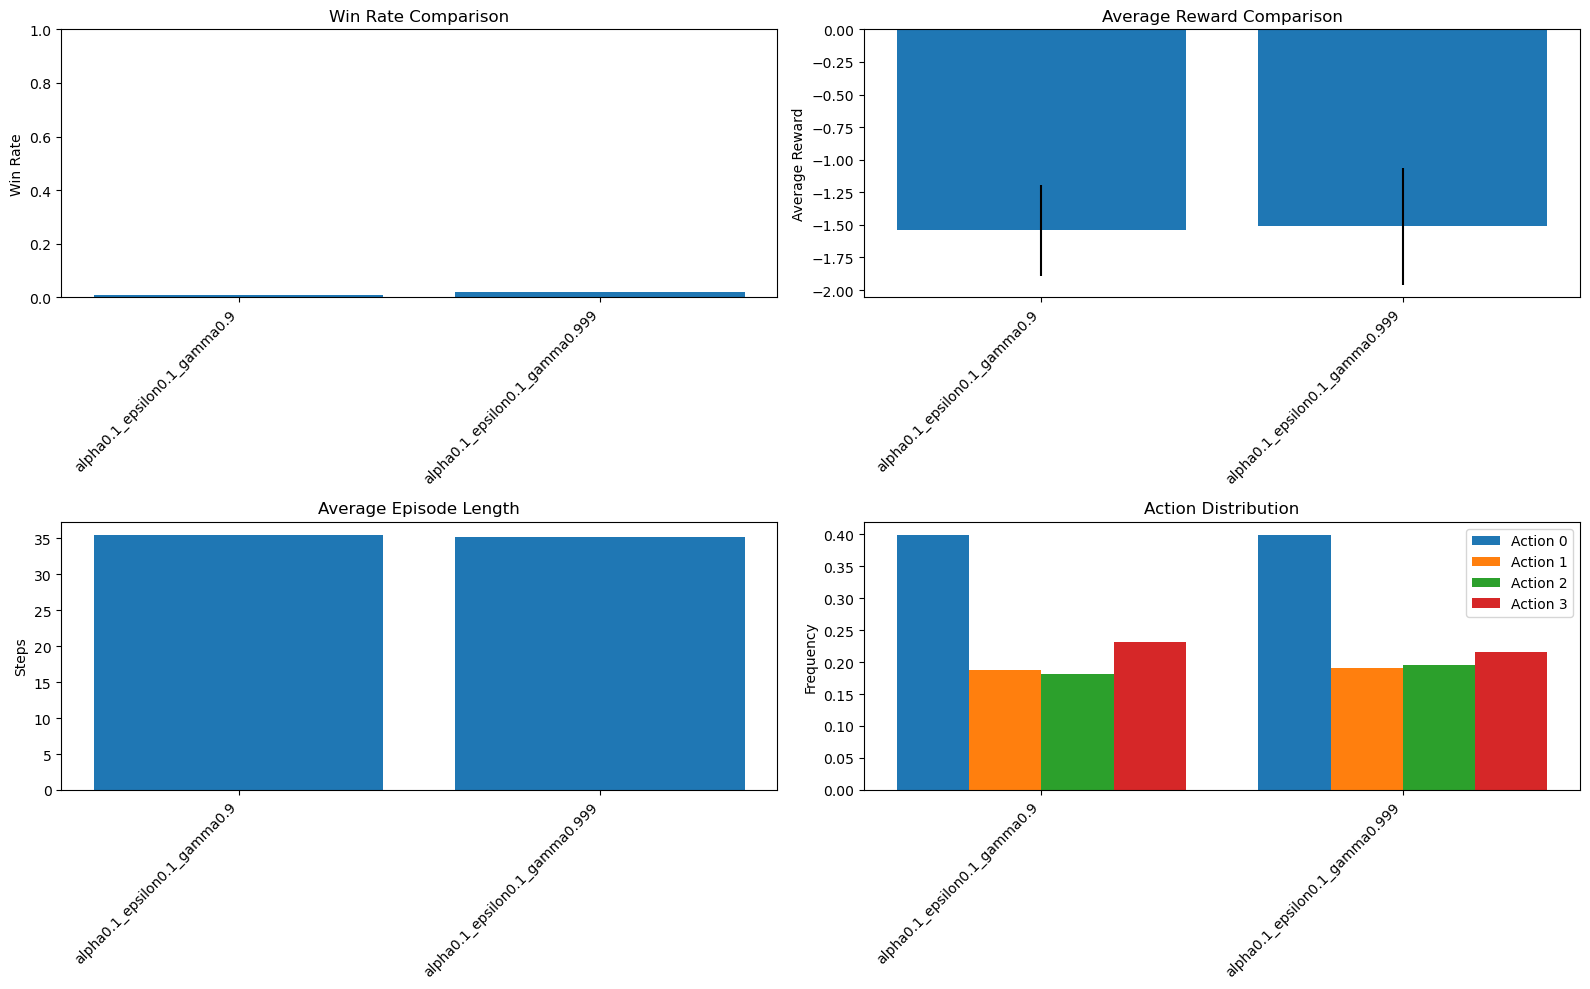

In [10]:
import numpy as np
import asyncio
import websockets
import json
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ClassPVPOKE import PVPokeEnv

def test_qtable(q_table_path, num_episodes=100, model_name=None, render=False, seed=None):
    """
    Test a Q-table against the environment for multiple episodes
    
    Args:
        q_table_path (str): Path to the Q-table file (.npy or .json)
        num_episodes (int): Number of test episodes to run
        model_name (str): Name of the model for display purposes
        render (bool): Whether to print episode results
        seed (int): Random seed for reproducibility
    
    Returns:
        dict: Statistics about the model's performance
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Initialize the environment
    env = PVPokeEnv("ws://localhost:8000/ws", "notebook", "pvpoke")
    env.loop.run_until_complete(env.connect())
    
    state_bins = env.observation_space.high + 1
    action_space_size = env.action_space.n
    
    # Load Q-table
    if q_table_path.endswith('.npy'):
        # NumPy array format
        Q = np.load(q_table_path)
        
        # Function to choose an action based on NumPy Q-table
        def choose_action_greedy(state):
            state_index = np.ravel_multi_index(state, state_bins)
            q_values = Q[state_index]
            max_indices = np.where(q_values == np.max(q_values))[0]
            return np.random.choice(max_indices)
            
    elif q_table_path.endswith('.json'):
        # JSON dictionary format
        with open(q_table_path, 'r') as f:
            Q = json.load(f)
        
        # Function to choose an action based on JSON Q-table
        def choose_action_greedy(state):
            state_str = str(tuple(state))
            # Check if state exists in our Q-table
            if state_str in Q:
                # Get all action values for this state
                q_values = [float(Q[state_str].get(str(a), 0)) for a in range(action_space_size)]
            else:
                # If state not found, use zeros or default values
                q_values = [0] * action_space_size
            
            # Find action with highest value (with random tie-breaking)
            max_q = max(q_values)
            max_indices = [i for i, q in enumerate(q_values) if q == max_q]
            return np.random.choice(max_indices)
    else:
        raise ValueError("Unsupported Q-table format. Use .npy or .json files.")
    
    model_name = model_name or os.path.basename(q_table_path)
    
    # Function to discretize the state
    def discretize_state(state):
        return tuple(state.astype(int))
    
    # Rest of your function remains the same...
    
    # Statistics to track
    total_rewards = []
    win_count = 0
    episode_lengths = []
    action_counts = np.zeros(action_space_size)
    episode_outcomes = []  # 1 for win, 0 for loss
    win_rewards = []
    lose_rewards = []
    
    start_time = time.time()
    
    # Testing loop
    for episode in range(num_episodes):
        state, _ = env.reset()
        state = discretize_state(state)
        episode_reward = 0
        steps = 0
        win_in_episode = False
        
        done = False
        while not done:
            action = choose_action_greedy(state)
            action_counts[action] += 1
            
            next_state, reward, done, _, _ = env.step(action)
            next_state = discretize_state(next_state)
            
            # Track if any reward in the episode indicates a win
            if reward >= 1:
                win_in_episode = True
            
            state = next_state
            episode_reward += reward
            steps += 1
        
        # Record statistics
        total_rewards.append(episode_reward)
        episode_lengths.append(steps)
        
        if win_in_episode:
            win_count += 1
            win_rewards.append(episode_reward)
            episode_outcomes.append(1)
        else:
            lose_rewards.append(episode_reward)
            episode_outcomes.append(0)
        
        if render and (episode % 10 == 0 or episode == num_episodes - 1):
            print(f"Episode {episode+1}/{num_episodes}, Reward: {episode_reward:.2f}, Steps: {steps}")
    
    # Calculate statistics and return results as before
    # ...
    test_time = time.time() - start_time
    # Calculate statistics
    win_rate = win_count / num_episodes
    avg_reward = np.mean(total_rewards)
    std_reward = np.std(total_rewards)
    avg_episode_length = np.mean(episode_lengths)
    action_distribution = action_counts / np.sum(action_counts)
    
    # Reward statistics by outcome
    avg_win_reward = np.mean(win_rewards) if win_rewards else 0
    avg_lose_reward = np.mean(lose_rewards) if lose_rewards else 0
    
    # Print summary
    print(f"\n===== Results for {model_name} =====\n")
    print(f"Win Rate: {win_rate:.2%} ({win_count}/{num_episodes})")
    print(f"Average Reward: {avg_reward:.4f} ± {std_reward:.4f}")
    print(f"Average Episode Length: {avg_episode_length:.2f} steps")
    print(f"Average Win Reward: {avg_win_reward:.4f}")
    print(f"Average Lose Reward: {avg_lose_reward:.4f}")
    print(f"Action Distribution: {action_distribution}")
    print(f"Testing Time: {test_time:.2f} seconds")
    
    env.close()
    
    return {
        'model_name': model_name,
        'win_rate': win_rate,
        'avg_reward': avg_reward,
        'std_reward': std_reward,
        'avg_episode_length': avg_episode_length,
        'action_distribution': action_distribution,
        'total_rewards': total_rewards,
        'episode_outcomes': episode_outcomes,
        'episode_lengths': episode_lengths,
        'avg_win_reward': avg_win_reward,
        'avg_lose_reward': avg_lose_reward,
        'test_time': test_time
    }

def compare_models(model_paths, num_episodes=100, seed=None):
    """
    Compare multiple Q-table models against each other
    
    Args:
        model_paths (list): List of dictionaries with 'path' and 'name' keys for each model
        num_episodes (int): Number of test episodes per model
        seed (int): Random seed for reproducibility
    
    Returns:
        dict: Comparison results
    """
    results = []
    
    for model in model_paths:
        path = model['path']
        name = model.get('name', os.path.basename(path))
        model_result = test_qtable(path, num_episodes, name, render=False, seed=seed)
        results.append(model_result)
        print("\n" + "-"*40 + "\n")
    
    # Create comparison visualizations
    plt.figure(figsize=(16, 10))
    
    # Plot win rates
    plt.subplot(2, 2, 1)
    model_names = [r['model_name'] for r in results]
    win_rates = [r['win_rate'] for r in results]
    plt.bar(model_names, win_rates)
    plt.title('Win Rate Comparison')
    plt.ylabel('Win Rate')
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    
    # Plot average rewards
    plt.subplot(2, 2, 2)
    avg_rewards = [r['avg_reward'] for r in results]
    std_rewards = [r['std_reward'] for r in results]
    plt.bar(model_names, avg_rewards, yerr=std_rewards)
    plt.title('Average Reward Comparison')
    plt.ylabel('Average Reward')
    plt.xticks(rotation=45, ha='right')
    
    # Plot episode lengths
    plt.subplot(2, 2, 3)
    avg_lengths = [r['avg_episode_length'] for r in results]
    plt.bar(model_names, avg_lengths)
    plt.title('Average Episode Length')
    plt.ylabel('Steps')
    plt.xticks(rotation=45, ha='right')
    
    # Plot action distributions
    plt.subplot(2, 2, 4)
    action_distributions = np.array([r['action_distribution'] for r in results])
    x = np.arange(len(model_names))
    width = 0.2
    for i in range(len(action_distributions[0])):
        plt.bar(x + i*width, action_distributions[:, i], width=width, label=f'Action {i}')
    plt.title('Action Distribution')
    plt.ylabel('Frequency')
    plt.xticks(x + width * (len(action_distributions[0])-1)/2, model_names, rotation=45, ha='right')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return {
        'results': results,
        'win_rates': win_rates,
        'avg_rewards': avg_rewards,
        'avg_lengths': avg_lengths
    }

# Example usage:

# Test a single model
test_results = test_qtable(
    "C:\pvpokeDRL\pvpoke\PVPOKE\experiments\Mantine-Gliglar-Terminal-1\grid_search_fixed\\alpha0.1_epsilon0.1_gamma0.9\q_table_final.json",
    num_episodes=50,
    model_name="Optimista (Default Action)",
    render=True
)

# Compare multiple models
comparison_results = compare_models([
    {
        'path': "C:\pvpokeDRL\pvpoke\PVPOKE\experiments\Mantine-Gliglar-Terminal-1\grid_search_fixed\\alpha0.1_epsilon0.1_gamma0.9\q_table_final.json",
        'name': "alpha0.1_epsilon0.1_gamma0.9"
    },
    {
        'path': "C:\pvpokeDRL\pvpoke\PVPOKE\experiments\Mantine-Gliglar-Terminal-1\grid_search_fixed\\alpha0.1_epsilon0.1_gamma0.999\q_table_final.json",
        'name': "alpha0.1_epsilon0.1_gamma0.999"
    }
])


Valor mínimo: -1.4036063140109278 en estado (0, 3, 0, 2, 2, 1), acción 3
Valor máximo: 2.0093729360435204 en estado (0, 1, 2, 1, 0, 2), acción 1


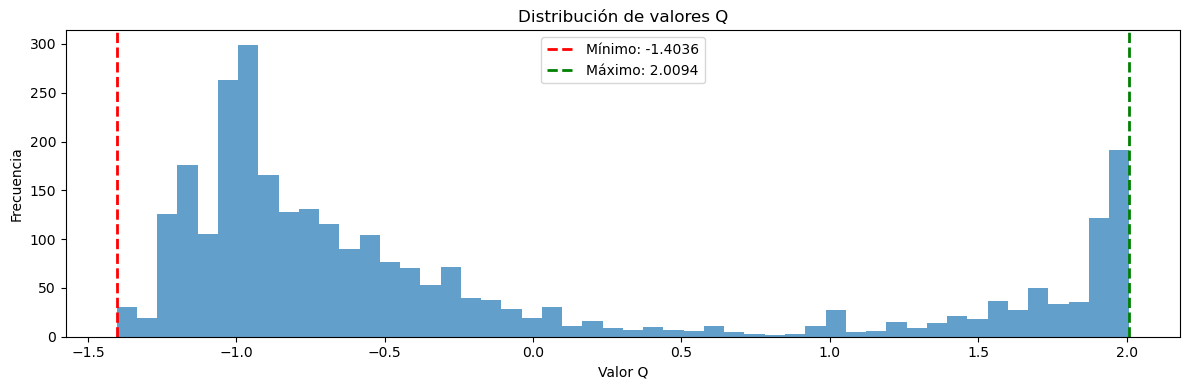

Total de valores Q: 2892
Porcentaje de estados explorados: 1.64%


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Cargar la tabla Q desde archivo JSON
q_table_path = "C:\pvpokeDRL\pvpoke\PVPOKE\experiments\Mantine-Gliglar-Terminal-3\grid_search_DiffHP\\alpha0.1_epsilon0.1_gamma0.999\q_table_final.json"
with open(q_table_path, 'r') as f:
    q_dict = json.load(f)

# Extraer todos los valores Q
all_q_values = []
max_value = float('-inf')
min_value = float('inf')
max_state = None
max_action = None
min_state = None
min_action = None

# Iterar sobre todos los estados y acciones
for state_str, actions in q_dict.items():
    for action_str, q_value in actions.items():
        q_value = float(q_value)
        all_q_values.append(q_value)
        
        # Actualizar máximo
        if q_value > max_value:
            max_value = q_value
            max_state = state_str
            max_action = action_str
            
        # Actualizar mínimo
        if q_value < min_value:
            min_value = q_value
            min_state = state_str
            min_action = action_str

print(f"Valor mínimo: {min_value} en estado {min_state}, acción {min_action}")
print(f"Valor máximo: {max_value} en estado {max_state}, acción {max_action}")

# Visualizar distribución con histograma
plt.figure(figsize=(12, 4))
plt.hist(all_q_values, bins=50, alpha=0.7)
plt.axvline(min_value, color='r', linestyle='dashed', linewidth=2, label=f'Mínimo: {min_value:.4f}')
plt.axvline(max_value, color='g', linestyle='dashed', linewidth=2, label=f'Máximo: {max_value:.4f}')
plt.title("Distribución de valores Q")
plt.xlabel("Valor Q")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total de valores Q: {len(all_q_values)}")
print(f"Porcentaje de estados explorados: {(len(q_dict)/44000)*100:.2f}%")

Analizando 40 checkpoints: [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500, 13000, 13500, 14000, 14500, 15000, 15500, 16000, 16500, 17000, 17500, 18000, 18500, 19000, 19500, 20000]

Analizando estado: (0, 5, 2, 0, 5, 2)


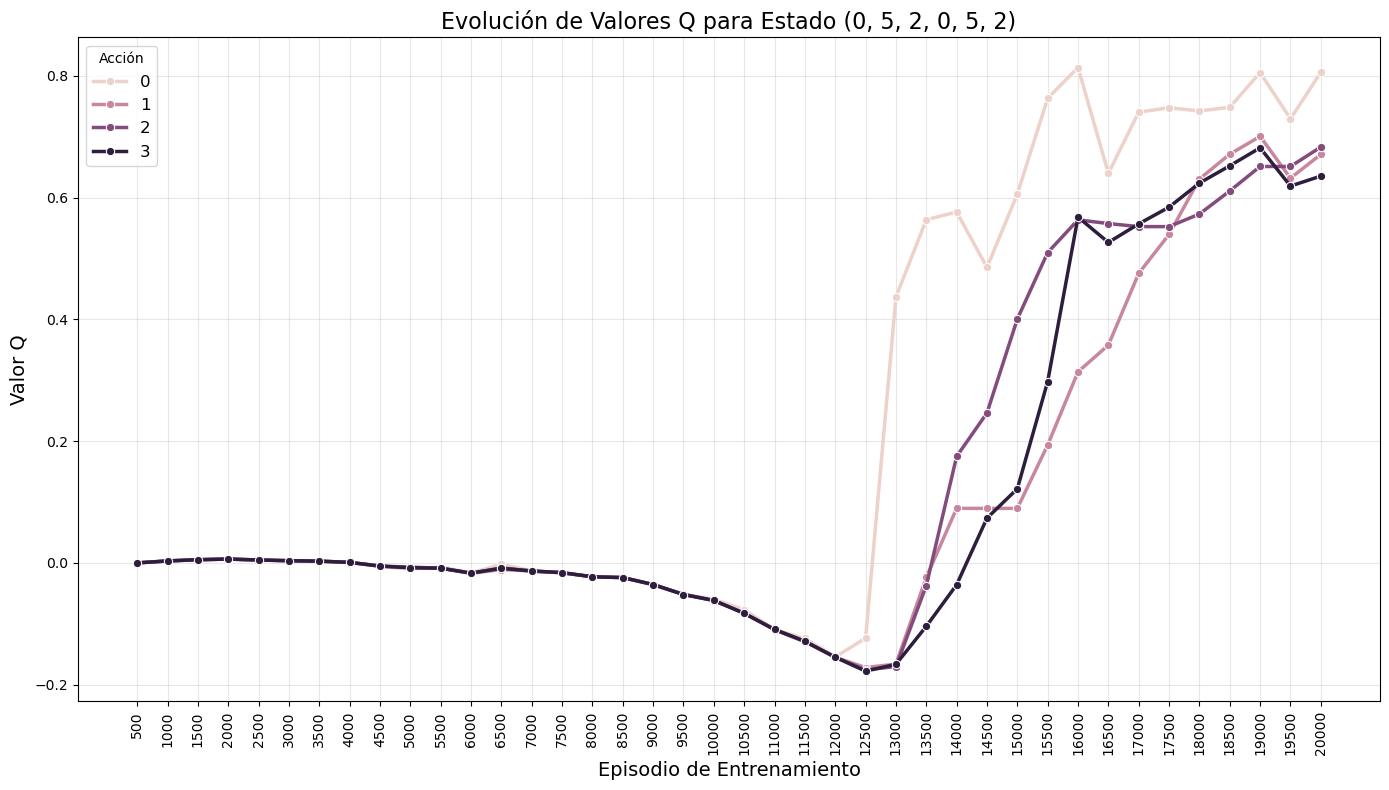

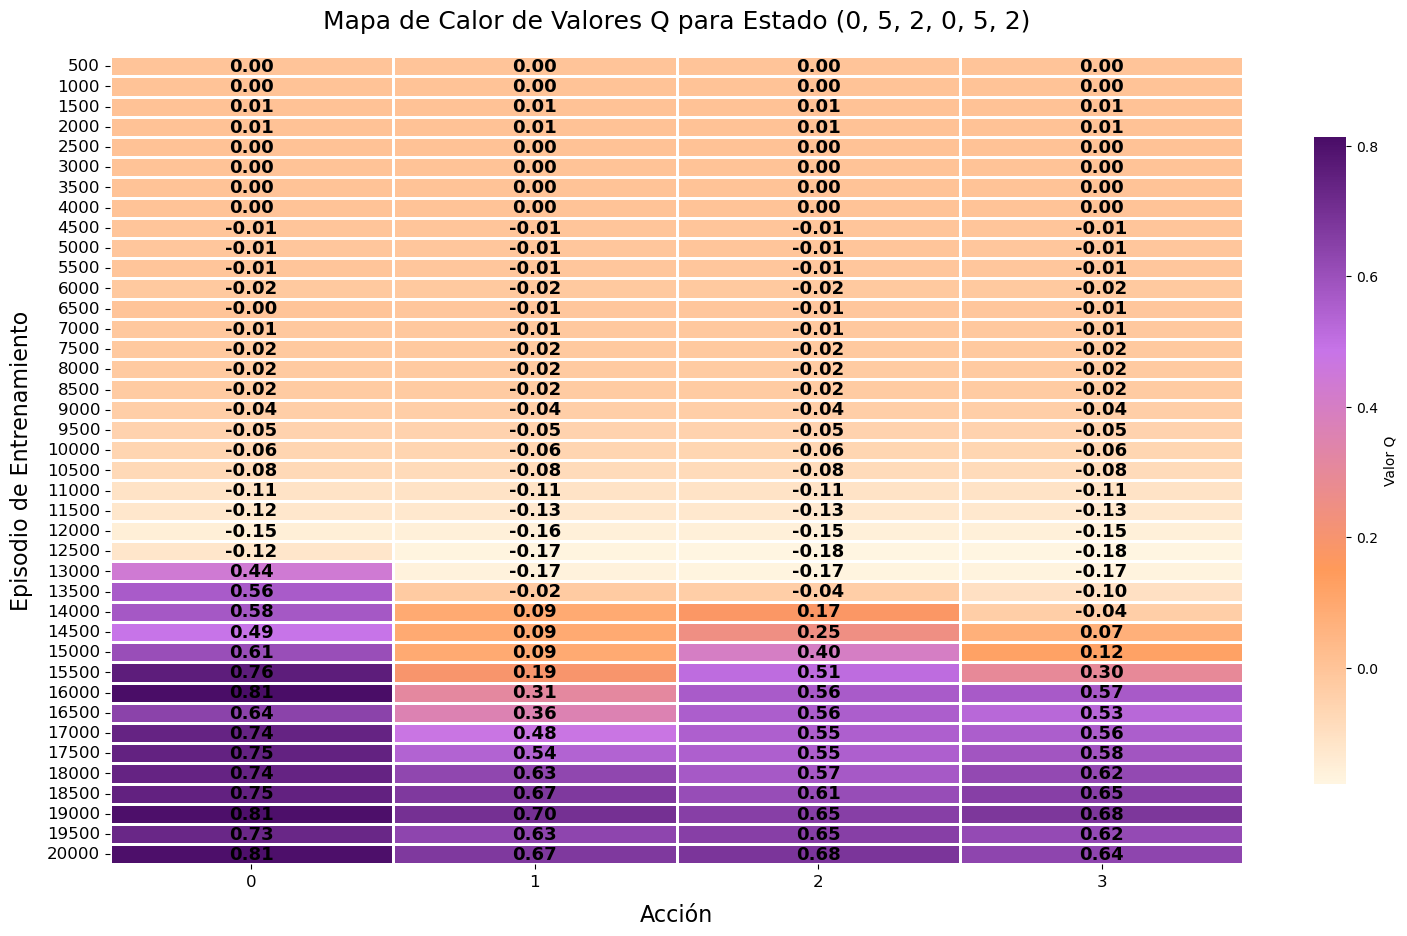

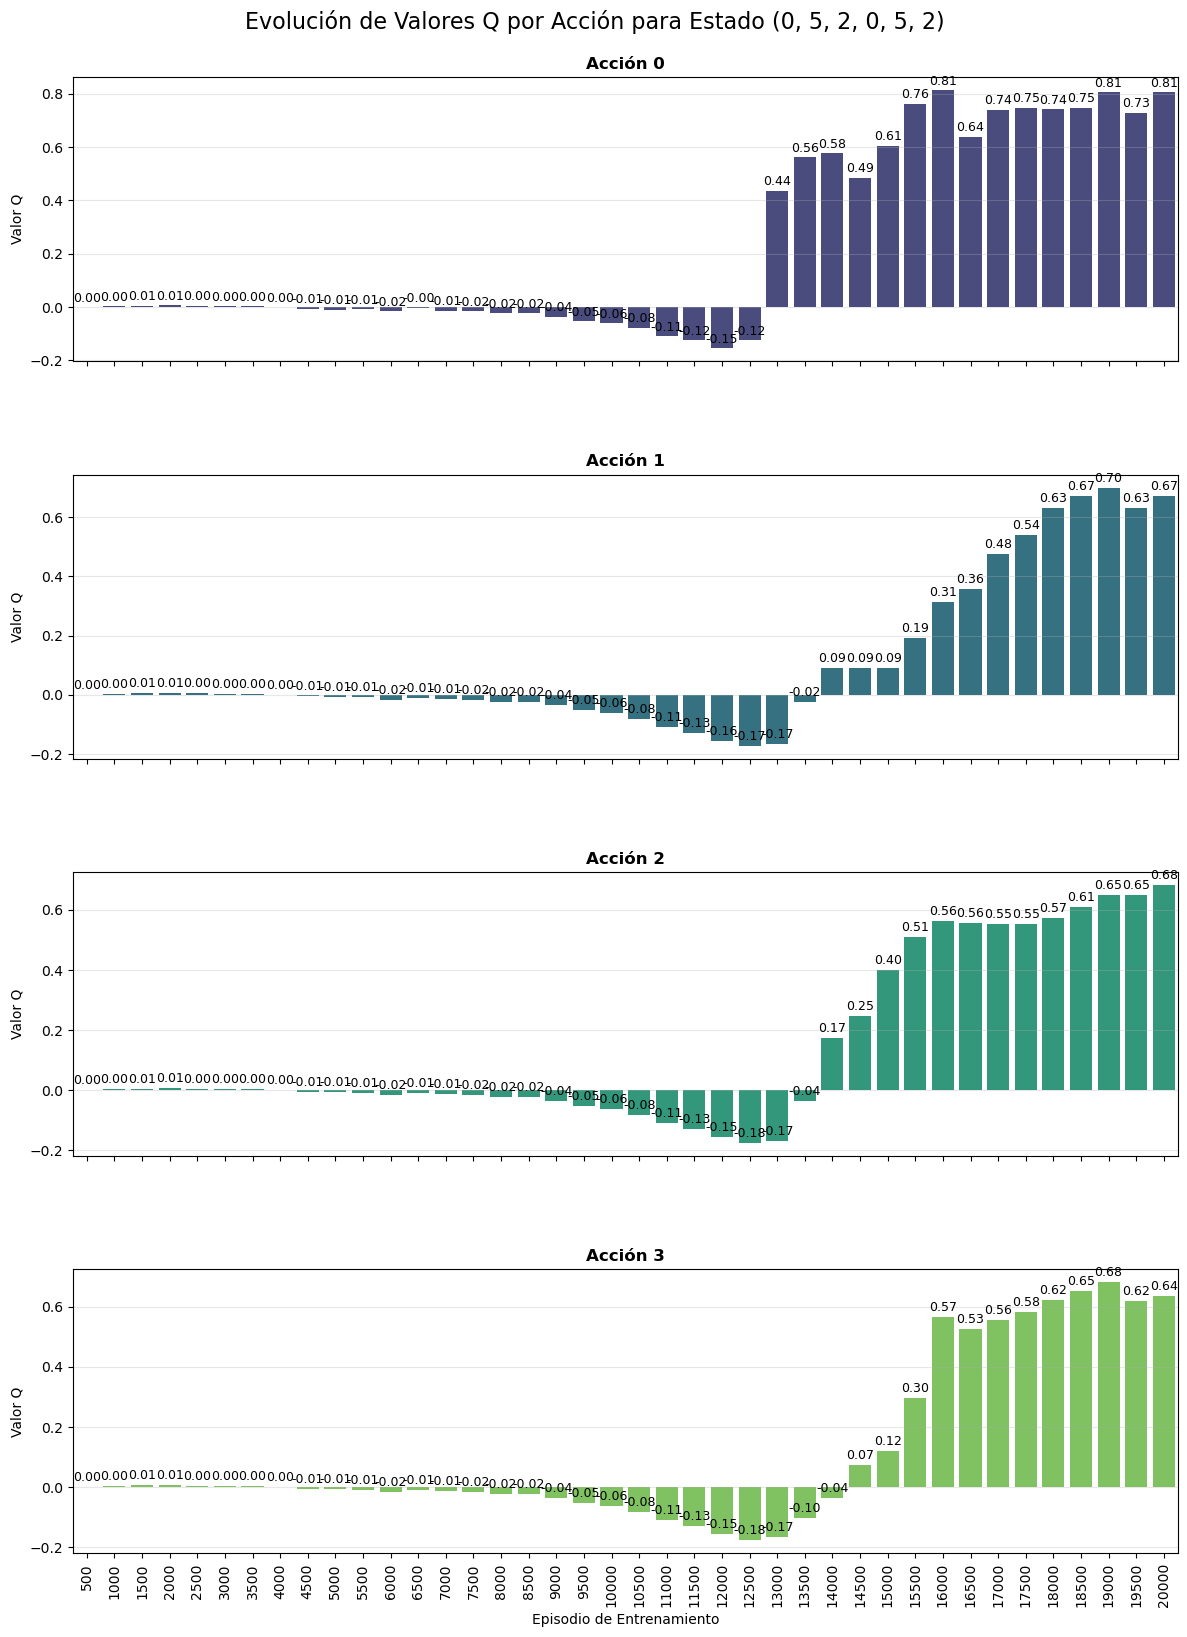


MEJOR ACCIÓN POR EPISODIO:
--------------------------
Episodio 500: Acción 1 (Valor Q: 0.00)
Episodio 1000: Acción 0 (Valor Q: 0.00)
Episodio 1500: Acción 0 (Valor Q: 0.01)
Episodio 2000: Acción 3 (Valor Q: 0.01)
Episodio 2500: Acción 3 (Valor Q: 0.00)
Episodio 3000: Acción 0 (Valor Q: 0.00)
Episodio 3500: Acción 1 (Valor Q: 0.00)
Episodio 4000: Acción 1 (Valor Q: 0.00)
Episodio 4500: Acción 3 (Valor Q: -0.01)
Episodio 5000: Acción 2 (Valor Q: -0.01)
Episodio 5500: Acción 0 (Valor Q: -0.01)
Episodio 6000: Acción 0 (Valor Q: -0.02)
Episodio 6500: Acción 0 (Valor Q: -0.00)
Episodio 7000: Acción 0 (Valor Q: -0.01)
Episodio 7500: Acción 0 (Valor Q: -0.02)
Episodio 8000: Acción 0 (Valor Q: -0.02)
Episodio 8500: Acción 0 (Valor Q: -0.02)
Episodio 9000: Acción 0 (Valor Q: -0.04)
Episodio 9500: Acción 2 (Valor Q: -0.05)
Episodio 10000: Acción 0 (Valor Q: -0.06)
Episodio 10500: Acción 0 (Valor Q: -0.08)
Episodio 11000: Acción 3 (Valor Q: -0.11)
Episodio 11500: Acción 0 (Valor Q: -0.12)
Episodi

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from glob import glob
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Estado inicial que queremos rastrear
estados_a_analizar = [
    (0, 5, 2, 0, 5, 2)  # Estado inicial con HP completo para ambos Pokémon
]

# Función para discretizar y asegurar que el estado esté dentro de los límites
def discretize_state(state, state_bins):
    """Convierte el estado a enteros y garantiza que esté dentro de los límites"""
    state = np.array(state).astype(int)
    # Asegurar que todos los valores estén dentro del rango [0, state_bins-1]
    state = np.clip(state, 0, state_bins - 1)
    return tuple(state)

# Directorio base donde se encuentran los checkpoints de la Q-table
base_dir = "C:\\pvpokeDRL\\pvpoke\\PVPOKE\\experiments\\Mantine-Gliglar-Terminal-Final\\NoOptimistic\\grid_search_RewardWinLoss\\alpha0.1_epsilon1_gamma1_epsilonmin0.01\\q_table"

# Recoge todos los archivos de tabla Q
archivos_q = glob(os.path.join(base_dir, "q_table_episode_*.json"))
if not archivos_q:
    archivos_q = glob(os.path.join(base_dir, "q_table_episode_*.npy"))

# Extrae el número de episodio de cada archivo y ordénalos
episodios = []
for archivo in archivos_q:
    match = re.search(r'episode_(\d+)', archivo)
    if match:
        episodios.append((int(match.group(1)), archivo))

# Ordenar por número de episodio
episodios.sort()
print(f"Analizando {len(episodios)} checkpoints: {[e[0] for e in episodios]}")

# Definimos state_bins para utilizarlo en clip y ravel_multi_index
state_bins = np.array([6, 6, 3, 6, 6, 3])

# Para cada estado de interés...
for estado_inicial in estados_a_analizar:
    # Asegurar que el estado inicial esté dentro de límites
    estado_inicial = discretize_state(estado_inicial, state_bins)
    estado_str = str(estado_inicial)  # Para formato JSON
    print(f"\nAnalizando estado: {estado_str}")
    
    # Recoger datos para la visualización
    datos_evolución = []
    
    # Extraer datos de cada archivo de checkpoint
    for episodio, archivo in episodios:
        if archivo.endswith('.json'):
            # Cargar tabla Q en formato JSON
            with open(archivo, 'r') as f:
                q_dict = json.load(f)
                
            # Extraer valores Q para el estado inicial
            if estado_str in q_dict:
                valores_q = q_dict[estado_str]
                for accion, valor in valores_q.items():
                    datos_evolución.append({
                        'Episodio': episodio,
                        'Acción': int(accion),
                        'Valor Q': float(valor)
                    })
            else:
                # Si el estado no está en la tabla Q, usar valores predeterminados
                for accion in range(5):  # Asumiendo 5 acciones
                    datos_evolución.append({
                        'Episodio': episodio,
                        'Acción': accion,
                        'Valor Q': 0.0  # Valor por defecto (neutral en lugar de optimista)
                    })
        
        elif archivo.endswith('.npy'):
            try:
                # Cargar tabla Q en formato NumPy
                q_table = np.load(archivo)
                
                # Calcular el índice del estado en la tabla NumPy (con seguridad)
                try:
                    state_index = np.ravel_multi_index(estado_inicial, state_bins)
                    
                    # Extraer valores Q para todas las acciones en este estado
                    for accion, valor in enumerate(q_table[state_index]):
                        datos_evolución.append({
                            'Episodio': episodio,
                            'Acción': accion,
                            'Valor Q': float(valor)
                        })
                except ValueError as e:
                    print(f"Error con el estado {estado_inicial} en archivo {archivo}: {e}")
                    # En caso de error, usar valores predeterminados
                    for accion in range(5):  # Asumiendo 5 acciones
                        datos_evolución.append({
                            'Episodio': episodio,
                            'Acción': accion,
                            'Valor Q': 0.0
                        })
            except Exception as e:
                print(f"Error al procesar archivo {archivo}: {e}")
    
    # Convertir a DataFrame para visualización
    df = pd.DataFrame(datos_evolución)
    
    if df.empty:
        print(f"No hay datos para el estado {estado_inicial}. Saltando visualización.")
        continue
    
    # 1. GRÁFICA DE LÍNEAS PARA VER EVOLUCIÓN COMPLETA
    plt.figure(figsize=(14, 8))
    sns.lineplot(
        data=df,
        x='Episodio',
        y='Valor Q',
        hue='Acción',
        marker='o',
        linewidth=2.5
    )
    
    # Título y etiquetas
    plt.title(f'Evolución de Valores Q para Estado {estado_inicial}', fontsize=16)
    plt.xlabel('Episodio de Entrenamiento', fontsize=14)
    plt.ylabel('Valor Q', fontsize=14)
    plt.legend(title='Acción', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Mejoras estéticas
    plt.xticks(sorted(df['Episodio'].unique()), rotation=90)
    plt.tight_layout()
    plt.show()
    
    # 2. MAPA DE CALOR MEJORADO CON MÁS ESPACIO Y NUEVO ESQUEMA DE COLORES
    plt.figure(figsize=(16, 10))  # Tamaño aumentado para más espacio
    
    # Crear el mapa de calor transpuesto (acciones como columnas, episodios como filas)
    pivot = df.pivot_table(index='Episodio', columns='Acción', values='Valor Q')
    
    # Crear un nuevo colormap personalizado - naranja a púrpura
    cmap = LinearSegmentedColormap.from_list('naranja_purpura', 
                                            [(0, '#FFF5E1'),      # Crema claro
                                             (0.33, '#FF9A5A'),   # Naranja
                                             (0.67, '#C774E8'),   # Púrpura
                                             (1, '#4A0D67')],     # Púrpura oscuro
                                             N=256)
    
    # Crear el heatmap con más espacio entre filas
    ax = sns.heatmap(pivot, 
                     annot=True,                   # Mostrar valores
                     fmt='.2f',                    # Formato de dos decimales
                     linewidths=2.0,               # Más ancho entre celdas 
                     linecolor='white',            # Color de las líneas divisorias
                     cmap=cmap,                    # Nuevo colormap
                     annot_kws={"size": 13,        # Texto más grande
                               "weight": "bold",   
                               "color": "black"},   # Texto en negro para mejor lectura
                     cbar_kws={"label": "Valor Q", 
                              "shrink": 0.8})      # Barra de color más pequeña
    
    # Ajustes adicionales para mejorar la apariencia
    plt.title(f'Mapa de Calor de Valores Q para Estado {estado_inicial}', fontsize=18, pad=20)
    plt.xlabel('Acción', fontsize=16, labelpad=10)
    plt.ylabel('Episodio de Entrenamiento', fontsize=16, labelpad=10)
    
    # Rotar etiquetas del eje Y (episodios) para mejor visualización
    plt.yticks(rotation=0, fontsize=12)
    plt.xticks(fontsize=12)
    
    # Añadir un poco de espacio alrededor del gráfico
    plt.tight_layout(pad=3.0)
    plt.show()
    
    # 3. GRÁFICAS SEPARADAS PARA CADA ACCIÓN
    num_acciones = len(df['Acción'].unique())
    fig, axes = plt.subplots(nrows=num_acciones, figsize=(12, 4*num_acciones), sharex=True)
    
    for i, accion in enumerate(sorted(df['Acción'].unique())):
        datos_accion = df[df['Acción'] == accion]
        
        ax = axes[i] if num_acciones > 1 else axes
        
        # Gráfica de barras para cada acción
        sns.barplot(x='Episodio', y='Valor Q', data=datos_accion, ax=ax, 
                   color=sns.color_palette("viridis", num_acciones)[i])
        
        # Añadir valor numérico encima de cada barra
        for j, valor in enumerate(datos_accion['Valor Q']):
            ax.text(j, valor + 0.02, f'{valor:.2f}', ha='center', fontsize=9)
        
        ax.set_title(f'Acción {accion}', fontweight='bold')
        ax.set_ylabel('Valor Q')
        ax.grid(alpha=0.3, axis='y')
        
        # Solo mostramos etiquetas X en el último gráfico
        if i == num_acciones-1 or num_acciones == 1:
            ax.set_xlabel('Episodio de Entrenamiento')
            plt.setp(ax.get_xticklabels(), rotation=90)
        else:
            ax.set_xlabel('')
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)  # Más espacio entre subgráficos
    plt.suptitle(f'Evolución de Valores Q por Acción para Estado {estado_inicial}', fontsize=16, y=1.02)
    plt.show()
    
    # 4. Información de la mejor acción en cada checkpoint
    print("\nMEJOR ACCIÓN POR EPISODIO:")
    print("--------------------------")
    for episodio in sorted(df['Episodio'].unique()):
        datos_episodio = df[df['Episodio'] == episodio]
        mejor = datos_episodio.loc[datos_episodio['Valor Q'].idxmax()]
        print(f"Episodio {episodio}: Acción {int(mejor['Acción'])} (Valor Q: {mejor['Valor Q']:.2f})")
    
    # Imprimir valores Q finales para cada acción
    ultimo_episodio = max(df['Episodio'])
    print(f"\nValores Q finales (Episodio {ultimo_episodio}):")
    print("-------------------------------")
    ultimos_valores = df[df['Episodio'] == ultimo_episodio].sort_values('Acción')
    for _, row in ultimos_valores.iterrows():
        print(f"Acción {int(row['Acción'])}: {row['Valor Q']:.4f}")
    
    # Identificar mejor acción final
    mejor_accion = ultimos_valores.loc[ultimos_valores['Valor Q'].idxmax()]
    print(f"\nMejor acción final: {int(mejor_accion['Acción'])} (Valor Q: {mejor_accion['Valor Q']:.4f})")

Analizando 150 checkpoints: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400, 14500, 14600, 14700, 14800, 14900, 15000]

Analizando estado: (2, 2, 1,

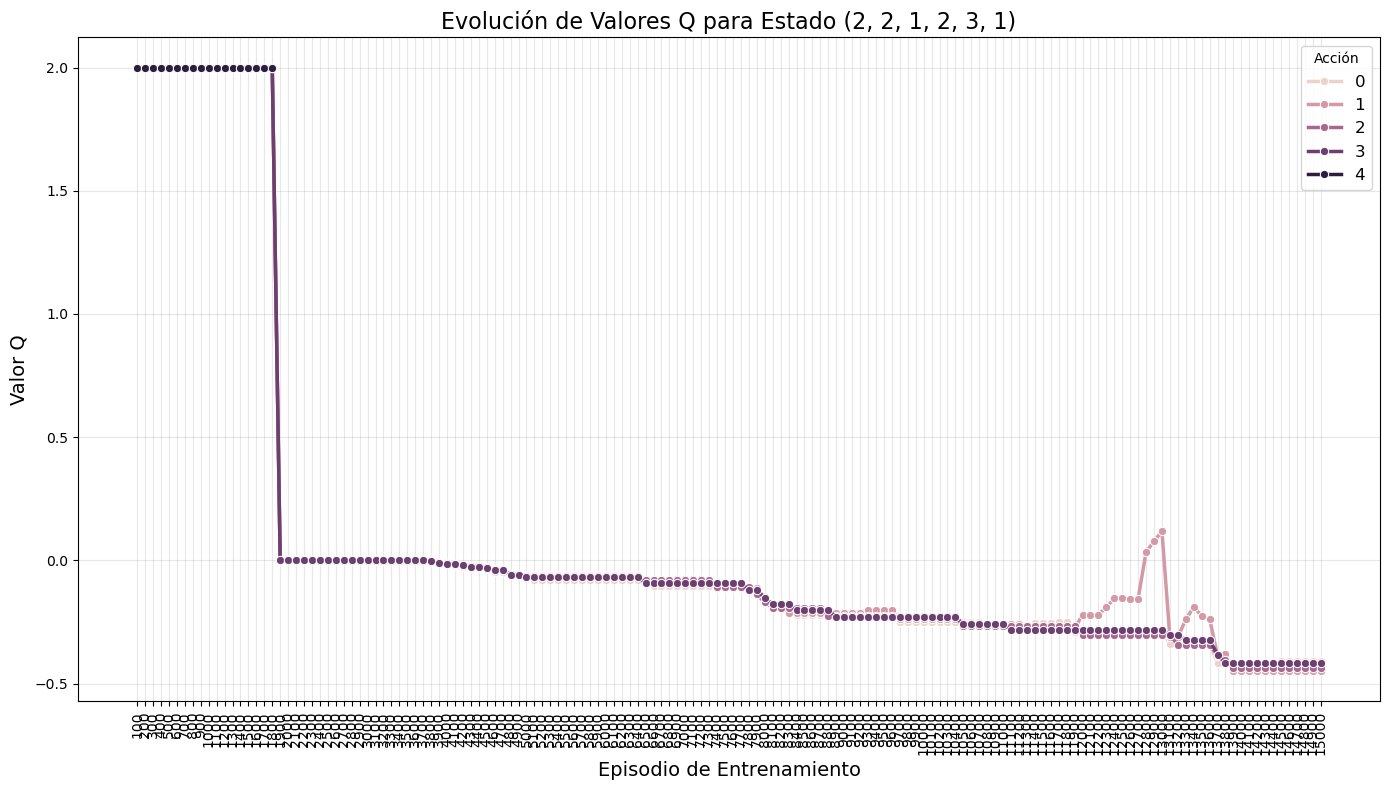

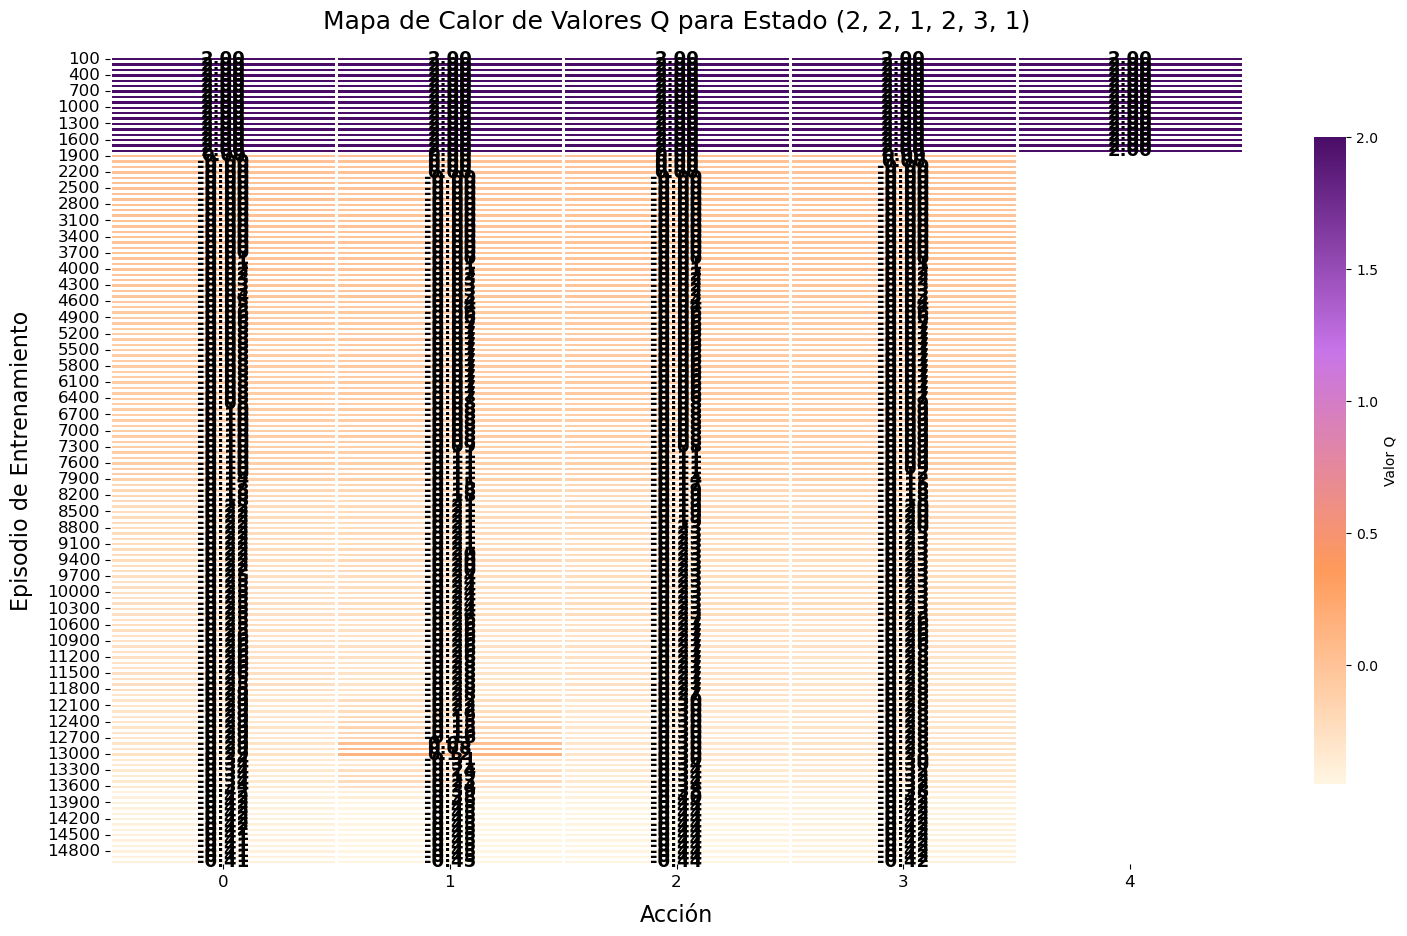

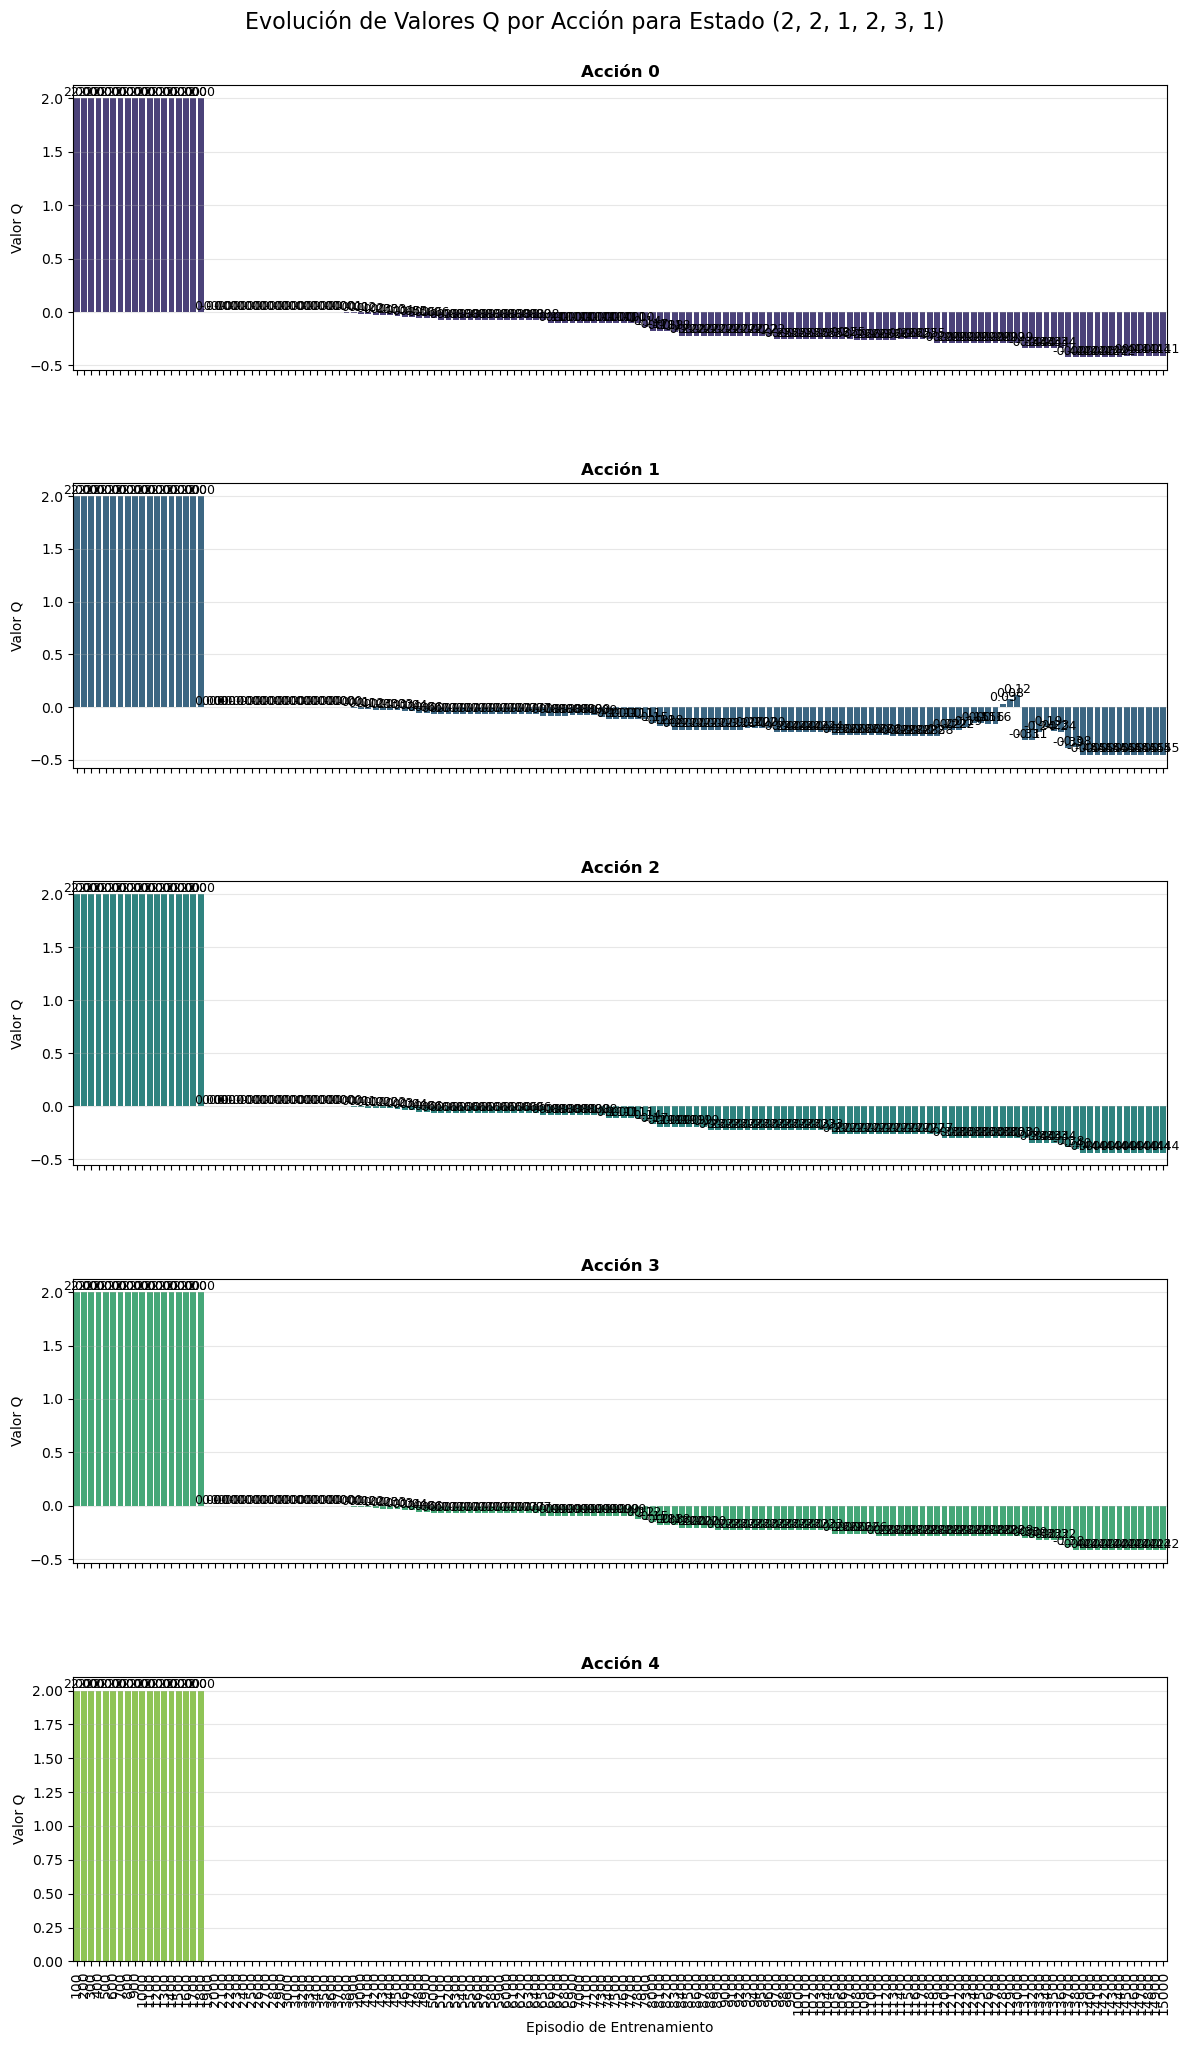


MEJOR ACCIÓN POR EPISODIO:
--------------------------
Episodio 100: Acción 0 (Valor Q: 2.00)
Episodio 200: Acción 0 (Valor Q: 2.00)
Episodio 300: Acción 0 (Valor Q: 2.00)
Episodio 400: Acción 0 (Valor Q: 2.00)
Episodio 500: Acción 0 (Valor Q: 2.00)
Episodio 600: Acción 0 (Valor Q: 2.00)
Episodio 700: Acción 0 (Valor Q: 2.00)
Episodio 800: Acción 0 (Valor Q: 2.00)
Episodio 900: Acción 0 (Valor Q: 2.00)
Episodio 1000: Acción 0 (Valor Q: 2.00)
Episodio 1100: Acción 0 (Valor Q: 2.00)
Episodio 1200: Acción 0 (Valor Q: 2.00)
Episodio 1300: Acción 0 (Valor Q: 2.00)
Episodio 1400: Acción 0 (Valor Q: 2.00)
Episodio 1500: Acción 0 (Valor Q: 2.00)
Episodio 1600: Acción 0 (Valor Q: 2.00)
Episodio 1700: Acción 0 (Valor Q: 2.00)
Episodio 1800: Acción 0 (Valor Q: 2.00)
Episodio 1900: Acción 0 (Valor Q: 0.00)
Episodio 2000: Acción 1 (Valor Q: 0.00)
Episodio 2100: Acción 1 (Valor Q: 0.00)
Episodio 2200: Acción 1 (Valor Q: 0.00)
Episodio 2300: Acción 0 (Valor Q: -0.00)
Episodio 2400: Acción 0 (Valor Q:

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from glob import glob
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Estado inicial que queremos rastrear
estados_a_analizar = [
    (0, 5, 2, 0, 5, 2)  # Estado inicial con HP completo para ambos Pokémon
]

# Directorio base donde se encuentran los checkpoints de la Q-table
base_dir = "C:\pvpokeDRL\\pvpoke\\PVPOKE\\experiments\\Mantine-Gliglar-Terminal-3\\NoOptimistic\\grid_search_RewardWinLoss-prueba\\alpha0.1_epsilon0.3_gamma0.99\\q_table"

# Recoge todos los archivos de tabla Q
archivos_q = glob(os.path.join(base_dir, "q_table_episode_*.json"))
if not archivos_q:
    archivos_q = glob(os.path.join(base_dir, "q_table_episode_*.npy"))

# Extrae el número de episodio de cada archivo y ordénalos
episodios = []
for archivo in archivos_q:
    match = re.search(r'episode_(\d+)', archivo)
    if match:
        episodios.append((int(match.group(1)), archivo))

# Ordenar por número de episodio
episodios.sort()
print(f"Analizando {len(episodios)} checkpoints: {[e[0] for e in episodios]}")

# Para cada estado de interés...
for estado_inicial in estados_a_analizar:
    estado_str = str(estado_inicial)  # Para formato JSON
    print(f"\nAnalizando estado: {estado_str}")
    
    # Recoger datos para la visualización
    datos_evolución = []
    
    # Extraer datos de cada archivo de checkpoint
    for episodio, archivo in episodios:
        if archivo.endswith('.json'):
            # Cargar tabla Q en formato JSON
            with open(archivo, 'r') as f:
                q_dict = json.load(f)
                
            # Extraer valores Q para el estado inicial
            if estado_str in q_dict:
                valores_q = q_dict[estado_str]
                for accion, valor in valores_q.items():
                    datos_evolución.append({
                        'Episodio': episodio,
                        'Acción': int(accion),
                        'Valor Q': float(valor)
                    })
            else:
                # Si el estado no está en la tabla Q, usar valores predeterminados (2.0 optimista)
                for accion in range(5):  # Asumiendo 5 acciones
                    datos_evolución.append({
                        'Episodio': episodio,
                        'Acción': accion,
                        'Valor Q': 2.0  # Valor por defecto (optimista)
                    })
        
        elif archivo.endswith('.npy'):
            # Cargar tabla Q en formato NumPy
            q_table = np.load(archivo)
            
            # Calcular el índice del estado en la tabla NumPy
            state_bins = np.array([6, 7, 3, 6, 7, 3])
            state_index = np.ravel_multi_index(estado_inicial, state_bins)
            
            # Extraer valores Q para todas las acciones en este estado
            for accion, valor in enumerate(q_table[state_index]):
                datos_evolución.append({
                    'Episodio': episodio,
                    'Acción': accion,
                    'Valor Q': float(valor)
                })
    
    # Convertir a DataFrame para visualización
    df = pd.DataFrame(datos_evolución)
    
    # 1. GRÁFICA DE LÍNEAS PARA VER EVOLUCIÓN COMPLETA
    plt.figure(figsize=(14, 8))
    sns.lineplot(
        data=df,
        x='Episodio',
        y='Valor Q',
        hue='Acción',
        marker='o',
        linewidth=2.5
    )
    
    # Título y etiquetas
    plt.title(f'Evolución de Valores Q para Estado {estado_inicial}', fontsize=16)
    plt.xlabel('Episodio de Entrenamiento', fontsize=14)
    plt.ylabel('Valor Q', fontsize=14)
    plt.legend(title='Acción', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Mejoras estéticas
    plt.xticks(sorted(df['Episodio'].unique()), rotation=90)
    plt.tight_layout()
    plt.show()
    
    # 2. MAPA DE CALOR MEJORADO CON MÁS ESPACIO Y NUEVO ESQUEMA DE COLORES
    plt.figure(figsize=(16, 10))  # Tamaño aumentado para más espacio
    
    # Crear el mapa de calor transpuesto (acciones como columnas, episodios como filas)
    pivot = df.pivot_table(index='Episodio', columns='Acción', values='Valor Q')
    
    # Crear un nuevo colormap personalizado - naranja a púrpura
    cmap = LinearSegmentedColormap.from_list('naranja_purpura', 
                                            [(0, '#FFF5E1'),      # Crema claro
                                             (0.33, '#FF9A5A'),   # Naranja
                                             (0.67, '#C774E8'),   # Púrpura
                                             (1, '#4A0D67')],     # Púrpura oscuro
                                             N=256)
    
    # Crear el heatmap con más espacio entre filas
    ax = sns.heatmap(pivot, 
                     annot=True,                   # Mostrar valores
                     fmt='.2f',                    # Formato de dos decimales
                     linewidths=2.0,               # Más ancho entre celdas 
                     linecolor='white',            # Color de las líneas divisorias
                     cmap=cmap,                    # Nuevo colormap
                     annot_kws={"size": 13,        # Texto más grande
                               "weight": "bold",   
                               "color": "black"},   # Texto en negro para mejor lectura
                     cbar_kws={"label": "Valor Q", 
                              "shrink": 0.8})      # Barra de color más pequeña
    
    # Ajustes adicionales para mejorar la apariencia
    plt.title(f'Mapa de Calor de Valores Q para Estado {estado_inicial}', fontsize=18, pad=20)
    plt.xlabel('Acción', fontsize=16, labelpad=10)
    plt.ylabel('Episodio de Entrenamiento', fontsize=16, labelpad=10)
    
    # Rotar etiquetas del eje Y (episodios) para mejor visualización
    plt.yticks(rotation=0, fontsize=12)
    plt.xticks(fontsize=12)
    
    # Añadir un poco de espacio alrededor del gráfico
    plt.tight_layout(pad=3.0)
    plt.show()
    
    # 3. GRÁFICAS SEPARADAS PARA CADA ACCIÓN
    num_acciones = len(df['Acción'].unique())
    fig, axes = plt.subplots(nrows=num_acciones, figsize=(12, 4*num_acciones), sharex=True)
    
    for i, accion in enumerate(sorted(df['Acción'].unique())):
        datos_accion = df[df['Acción'] == accion]
        
        ax = axes[i] if num_acciones > 1 else axes
        
        # Gráfica de barras para cada acción
        sns.barplot(x='Episodio', y='Valor Q', data=datos_accion, ax=ax, 
                   color=sns.color_palette("viridis", num_acciones)[i])
        
        # Añadir valor numérico encima de cada barra
        for j, valor in enumerate(datos_accion['Valor Q']):
            ax.text(j, valor + 0.02, f'{valor:.2f}', ha='center', fontsize=9)
        
        ax.set_title(f'Acción {accion}', fontweight='bold')
        ax.set_ylabel('Valor Q')
        ax.grid(alpha=0.3, axis='y')
        
        # Solo mostramos etiquetas X en el último gráfico
        if i == num_acciones-1 or num_acciones == 1:
            ax.set_xlabel('Episodio de Entrenamiento')
            plt.setp(ax.get_xticklabels(), rotation=90)
        else:
            ax.set_xlabel('')
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)  # Más espacio entre subgráficos
    plt.suptitle(f'Evolución de Valores Q por Acción para Estado {estado_inicial}', fontsize=16, y=1.02)
    plt.show()
    
    # 4. Información de la mejor acción en cada checkpoint
    print("\nMEJOR ACCIÓN POR EPISODIO:")
    print("--------------------------")
    for episodio in sorted(df['Episodio'].unique()):
        datos_episodio = df[df['Episodio'] == episodio]
        mejor = datos_episodio.loc[datos_episodio['Valor Q'].idxmax()]
        print(f"Episodio {episodio}: Acción {int(mejor['Acción'])} (Valor Q: {mejor['Valor Q']:.2f})")
    
    # Imprimir valores Q finales para cada acción
    ultimo_episodio = max(df['Episodio'])
    print(f"\nValores Q finales (Episodio {ultimo_episodio}):")
    print("-------------------------------")
    ultimos_valores = df[df['Episodio'] == ultimo_episodio].sort_values('Acción')
    for _, row in ultimos_valores.iterrows():
        print(f"Acción {int(row['Acción'])}: {row['Valor Q']:.4f}")
    
    # Identificar mejor acción final
    mejor_accion = ultimos_valores.loc[ultimos_valores['Valor Q'].idxmax()]
    print(f"\nMejor acción final: {int(mejor_accion['Acción'])} (Valor Q: {mejor_accion['Valor Q']:.4f})")

# Evaluacion q

Connected to the server.

🏆 BATTLE START 🏆

Initial State: (0, 20, 2, 0, 20, 2)

Step 1:
State: (0, 20, 2, 0, 20, 2)
Q-values for each action:
  ✓ Fast Move: 0.7711
    Charge Move 1: 0.4611
    Charge Move 2: 0.3343
    Switch: 0.2540

--- Step 1 ---
State: (0, 20, 2, 0, 20, 2)
Action: 0 (Fast Move)
Reward: 0
Next State: (2, 20, 2, 2, 20, 2)

Step 2:
State: (2, 20, 2, 2, 20, 2)
Q-values for each action:
  ✓ Fast Move: 0.7764
    Charge Move 1: 0.4052
    Charge Move 2: 0.3975
    Switch: 0.4111

--- Step 2 ---
State: (2, 20, 2, 2, 20, 2)
Action: 0 (Fast Move)
Reward: 0
Next State: (3, 19, 2, 3, 19, 2)

Step 3:
State: (3, 19, 2, 3, 19, 2)
Q-values for each action:
    Fast Move: 0.2390
    Charge Move 1: 0.4162
    Charge Move 2: 0.5597
  ✓ Switch: 0.7810

--- Step 3 ---
State: (3, 19, 2, 3, 19, 2)
Action: 3 (Switch)
Reward: 0
Next State: (3, 19, 2, 3, 19, 2)

Step 4:
State: (3, 19, 2, 3, 19, 2)
Q-values for each action:
    Fast Move: 0.2390
    Charge Move 1: 0.4162
    Charge Move 2

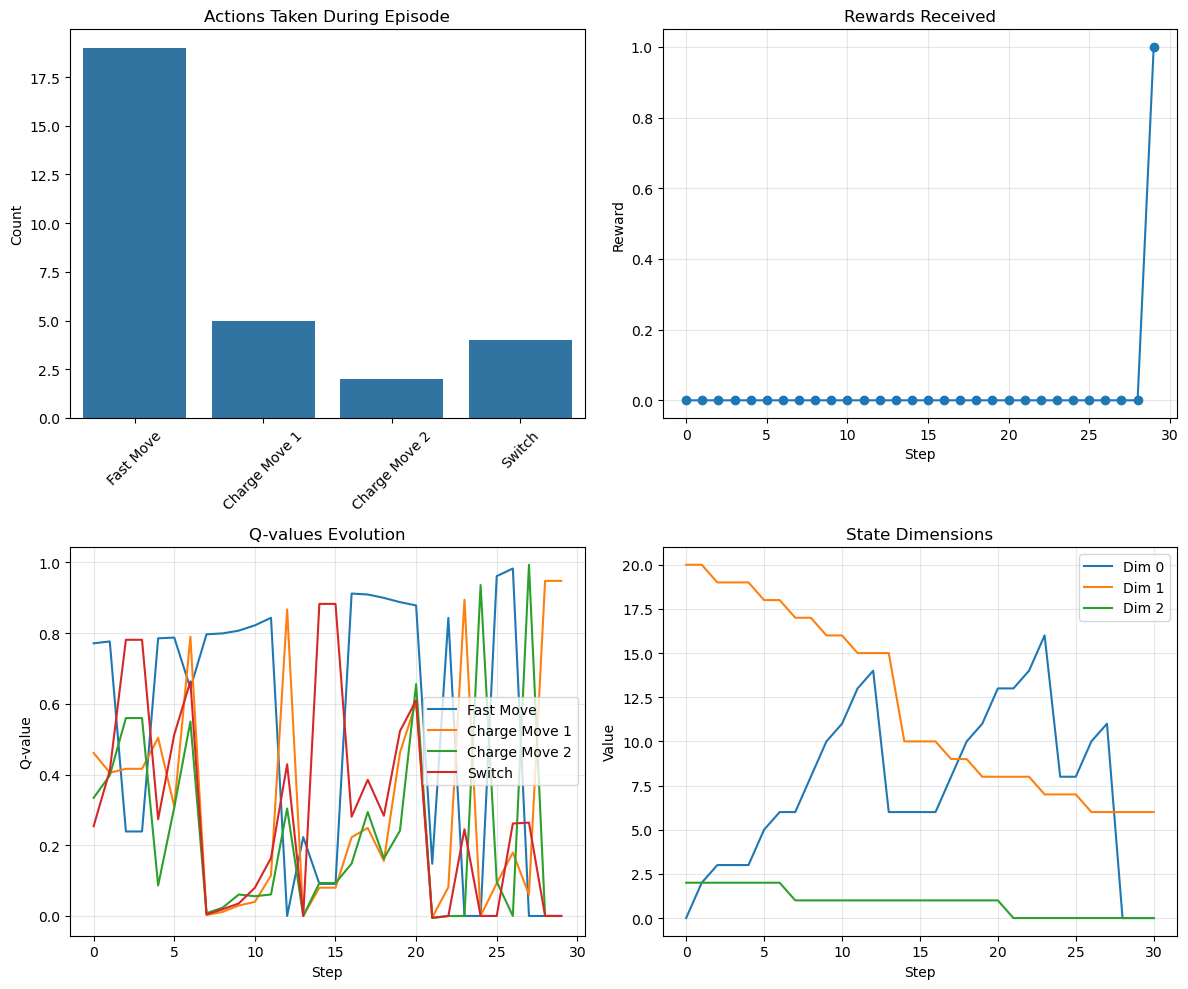

WebSocket connection closed.

===== Episode Summary =====
Total Steps: 30
Total Reward: 1
Outcome: Won


In [12]:
import numpy as np
import asyncio
import json
import matplotlib.pyplot as plt
import seaborn as sns
from ClassPVPOKE import PVPokeEnv
import time
from IPython.display import display, clear_output

def evaluate_single_episode(q_table_path, render=True, seed=None, verbose=True):
    """
    Evaluate a single episode using a trained Q-table and display detailed information
    
    Args:
        q_table_path (str): Path to the Q-table file (.npy or .json)
        render (bool): Whether to print state transitions
        seed (int): Random seed for reproducibility
        verbose (bool): Whether to print detailed Q-values for each state
    
    Returns:
        dict: Statistics about the episode
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Initialize the environment
    env = PVPokeEnv("ws://localhost:8000/ws", "notebook", "pvpoke", battle_format="1v1")
    env.loop.run_until_complete(env.connect())
    
    state_bins = env.observation_space.high + 1
    action_space_size = env.action_space.n
    
    # Load Q-table
    if q_table_path.endswith('.npy'):
        # NumPy array format
        Q = np.load(q_table_path)
        
        def get_q_values(state):
            state_index = np.ravel_multi_index(state, state_bins)
            return Q[state_index]
            
    elif q_table_path.endswith('.json'):
        # JSON dictionary format
        with open(q_table_path, 'r') as f:
            Q = json.load(f)
        
        def get_q_values(state):
            state_str = str(tuple(state))
            # Check if state exists in our Q-table
            if state_str in Q:
                # Get all action values for this state
                return [float(Q[state_str].get(str(a), 0)) for a in range(action_space_size)]
            else:
                # If state not found, use zeros or default values
                return [0] * action_space_size
    else:
        raise ValueError("Unsupported Q-table format. Use .npy or .json files.")
    
    # Function to discretize the state
    def discretize_state(state):
        return tuple(state.astype(int))
    
    # Function to choose action (greedy policy)
    def choose_action_greedy(state):
        q_values = get_q_values(state)
        max_indices = np.where(np.array(q_values) == np.max(q_values))[0]
        return np.random.choice(max_indices)
    
    # Initialize tracking variables
    episode_steps = []
    episode_rewards = []
    actions_taken = []
    states_visited = []
    q_values_history = []
    
    # Action names for better readability (adjust based on your environment)
    action_names = ["Fast Move", "Charge Move 1", "Charge Move 2", "Switch", "Shield"]
    
    # Run a single episode
    state, _ = env.reset()
    state = discretize_state(state)
    states_visited.append(state)
    
    total_reward = 0
    done = False
    step = 0
    
    if render:
        print("\n🏆 BATTLE START 🏆\n")
        print(f"Initial State: {state}")
    
    while not done:
        # Get Q-values for current state
        q_values = get_q_values(state)
        q_values_history.append(q_values)
        
        # Choose action
        action = choose_action_greedy(state)
        actions_taken.append(action)
        
        if verbose:
            print(f"\nStep {step+1}:")
            print(f"State: {state}")
            print("Q-values for each action:")
            for i, q_val in enumerate(q_values):
                action_name = action_names[i] if i < len(action_names) else f"Action {i}"
                marker = "✓" if i == action else " "
                print(f"  {marker} {action_name}: {q_val:.4f}")
        
        # Take action
        next_state, reward, done, _, _ = env.step(action)
        next_state = discretize_state(next_state)
        
        # Record data
        states_visited.append(next_state)
        episode_rewards.append(reward)
        episode_steps.append({
            'state': state,
            'action': action,
            'action_name': action_names[action] if action < len(action_names) else f"Action {action}",
            'reward': reward,
            'next_state': next_state,
            'q_values': q_values.copy() if isinstance(q_values, list) else q_values.tolist()
        })
        
        if render:
            print(f"\n--- Step {step+1} ---")
            print(f"State: {state}")
            print(f"Action: {action} ({action_names[action] if action < len(action_names) else f'Action {action}'})")
            print(f"Reward: {reward}")
            print(f"Next State: {next_state}")
            if done:
                print("\n🎮 BATTLE FINISHED 🎮")
                if reward > 0:
                    print("🏆 VICTORY! 🏆")
                else:
                    print("❌ DEFEAT ❌")
        
        # Update for next step
        state = next_state
        total_reward += reward
        step += 1
    
    # Create visualizations
    plt.figure(figsize=(12, 10))
    
    # 1. Action distribution
    plt.subplot(2, 2, 1)
    action_counts = np.bincount(actions_taken, minlength=action_space_size)
    action_labels = [action_names[i] if i < len(action_names) else f"Action {i}" for i in range(action_space_size)]
    sns.barplot(x=action_labels, y=action_counts)
    plt.title('Actions Taken During Episode')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    # 2. Rewards per step
    plt.subplot(2, 2, 2)
    plt.plot(episode_rewards, marker='o')
    plt.title('Rewards Received')
    plt.xlabel('Step')
    plt.ylabel('Reward')
    plt.grid(True, alpha=0.3)
    
    # 3. Q-values evolution
    plt.subplot(2, 2, 3)
    q_values_array = np.array(q_values_history)
    for i in range(action_space_size):
        if i < len(q_values_array[0]):
            plt.plot(q_values_array[:, i], label=action_labels[i])
    plt.title('Q-values Evolution')
    plt.xlabel('Step')
    plt.ylabel('Q-value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4. State transitions (just showing a few dimensions)
    plt.subplot(2, 2, 4)
    states_array = np.array(states_visited)
    for i in range(min(3, states_array.shape[1])):  # Show up to 3 dimensions
        plt.plot(states_array[:, i], label=f'Dim {i}')
    plt.title('State Dimensions')
    plt.xlabel('Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Clean up
    env.close()
    
    outcome = "Won" if episode_rewards[-1] > 0 else "Lost"
    
    print("\n===== Episode Summary =====")
    print(f"Total Steps: {step}")
    print(f"Total Reward: {total_reward}")
    print(f"Outcome: {outcome}")
    
    return {
        'total_steps': step,
        'total_reward': total_reward,
        'outcome': outcome,
        'actions_taken': actions_taken,
        'action_names_taken': [action_names[a] if a < len(action_names) else f"Action {a}" for a in actions_taken],
        'rewards': episode_rewards,
        'states': states_visited,
        'q_values': q_values_history,
        'episode_steps': episode_steps
    }

# Example usage:
result = evaluate_single_episode(
    "C:\pvpokeDRL\\pvpoke\\PVPOKE\\experiments\\Mantine-Gliglar-Terminal--20Niveles\\NoOptimistic\\grid_search_RewardWinLoss\\alpha0.1_epsilon1_gamma0.999_epsilonmin0.01\\q_table\\q_table_episode_20000.json",
    render=True,
    verbose=True
)